# Differentiable digital audio: parametric EQ + dynamic-range compressor

A mastering chain is a control system. Three biquad filters in series form a parametric equaliser; a rectifier-plus-one-pole-low-pass-plus-smooth-knee forms a feed-forward dynamic-range compressor. Run them at 44.1 kHz with a 1 kHz envelope-follower side-chain, and we have the standard mix-bus topology that every commercial DAW ships. Implement them inside `jaxonomy` and a `jax.grad` of integrated loudness with respect to the compressor's threshold, ratio, attack, and release falls out — and a 20-step L-BFGS-B run tunes the compressor to a target loudness in seconds, work that today's plug-in workflow does by ear over hours.

**Estimated reading time**: 25 minutes. **Estimated runtime on CPU**: ~2 minutes (default publication mode loads the autotune trajectory from a checkpoint; fast mode re-runs it in ~30 s).

**Prerequisites**: comfort with `DiagramBuilder` / `simulate` (see [`primitives.ipynb`](primitives.ipynb)) and gradient-based parameter tuning (see [`pid_2dof_classical_tuning.ipynb`](pid_2dof_classical_tuning.ipynb)). No prior DSP / audio engineering background required; we derive the biquad coefficients and the compressor knee from first principles.

## Why a control-systems library for audio DSP

Audio plug-ins are LTI filters and (slow-time-varying) nonlinear gain stages. The filter half is exactly what jaxonomy's discrete-time block family was built for: difference equations with differentiable coefficients, scheduled at a fixed sample rate. The nonlinear half — the compressor knee — is precisely the smooth-saturation primitive `SoftSaturate` exposes. So an end-to-end mastering chain is a `Diagram` like any other.

What we gain by putting it in `jaxonomy` rather than NumPy is **gradients across the whole chain**. The dominant audio-mastering workflow today is iterative ear-tuning — adjust a knob, A/B against a reference recording, repeat. Commercial AI-assisted mastering services (LANDR, eMastered, iZotope Master Assistant) automate this with a learned policy that maps a spectral signature to a setting; none of them are *end-to-end differentiable* through the chain.

If we make the chain differentiable, we can solve any of these problems by 20 lines of `jax.grad` plus `scipy.optimize`:

- *Match a target loudness.* Take `jax.grad((measured_LUFS - target_LUFS)**2)` w.r.t. compressor parameters; descend.
- *Match a reference recording's spectrum.* Take `jax.grad(||spectrum(out) - spectrum(ref)||^2)` w.r.t. EQ band gains; descend.
- *Find the input samples a compressor cares most about.* Take `jax.grad(out)` w.r.t. the *input signal* and inspect the per-sample sensitivity.

All three are out-of-reach in the conventional audio-plug-in stack. The first two we demonstrate live; the third is left as an exercise.

> **Note**: this tutorial implements the *forward* differentiable chain end-to-end. Real-time deployment is a separate problem (jaxonomy is not a real-time DAW backend); we discuss the gap explicitly in §11.

## The signal chain

Our chain takes a 5-second stereo-summed-to-mono musical signal (pink noise for the body, a transient kick for the punch, a sustained sine for the tonal centre) through three stages:

1. **Parametric equaliser** — three biquad bands: an 80 Hz low-shelf for bass, a 1.5 kHz peaking band for vocal/instrumental presence, and an 8 kHz high-shelf for air.
2. **Envelope follower** — full-wave rectification and an asymmetric one-pole filter at 1 kHz (attack ~5 ms, release ~50 ms) that tracks the slow-varying signal level.
3. **Dynamic-range compressor** — a smooth-knee (`SoftSaturate`-shaped) static-gain curve in the log domain, applied as a linear gain on the audio path with optional make-up gain.

This is the standard textbook feed-forward mastering compressor, after Reiss \& McPherson (2014, §6) and the Zölzer (2002) DAFX text. The 44.1 kHz audio rate and 1 kHz control rate are both standard practice: a slow-varying envelope is a smoothed signal level, so running the side-chain at 1/44 the audio rate costs nothing in quality and buys a factor of $\sim 44$ in side-chain compute. We bridge the two rates with jaxonomy's `RateTransition`, which auto-selects a `Decimator` (fast → slow) or a `ZeroOrderHold` (slow → fast) depending on the direction of the edge.

### Variable conventions

| Symbol | Meaning | Units |
|---|---|---|
| $x[k]$ | input audio sample at index $k$ | dimensionless (normalised, $\sim \pm 1$) |
| $y[k]$ | output audio sample | dimensionless |
| $f_s$ | audio sample rate | Hz |
| $f_c$ | control-side (envelope) sample rate | Hz |
| $f_0$ | EQ band centre / shelf frequency | Hz |
| $Q$ | EQ band quality factor (dimensionless; controls bandwidth) | — |
| $G$ | EQ band peak gain | dB |
| $e[k]$ | envelope-follower output | dimensionless |
| $\tau_a, \tau_r$ | envelope attack / release time constants | s |
| $T$ | compressor threshold | dB |
| $R$ | compressor ratio | dimensionless ($R \geq 1$) |
| $W$ | compressor knee half-width | dB |
| $g[k]$ | compressor gain reduction | dB (always $\leq 0$) |

In [1]:
import os
import time
import warnings

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

import jaxonomy
from jaxonomy import DiagramBuilder, LeafSystem, SimulatorOptions, simulate
from jaxonomy.backend import numpy_api as npa
from jaxonomy.framework import DependencyTicket, parameters
from jaxonomy.library import (
    Adder,
    Constant,
    Decimator,
    LowPassDiscrete,
    Product,
    soft_saturate,
)
from jaxonomy.diagnostics import analyze_control_oscillation, analyze_saturation
from jaxonomy import logging as jaxlog

jaxlog.set_log_level(jaxlog.ERROR)
warnings.filterwarnings("ignore", message="period is None")

# Reproducibility - every random draw in this notebook is keyed off here.
SEED = 0
KEY = jax.random.PRNGKey(SEED)
np_rng = np.random.default_rng(SEED)

# Sample rates.
FS_AUDIO = 44_100.0     # audio sample rate [Hz]
FS_CTRL = 1_000.0       # envelope-follower sample rate [Hz]
DT_AUDIO = 1.0 / FS_AUDIO
DT_CTRL = 1.0 / FS_CTRL

# Test-clip duration. Total samples = T_CLIP * FS_AUDIO.
T_CLIP = 5.0
N_AUDIO = int(T_CLIP * FS_AUDIO)        # 220_500 samples at 44.1 kHz

# A *short* clip used only for the in-notebook DiagramBuilder simulation
# (the full clip is run via lax.scan, which is ~50x faster end-to-end).
T_DEMO = 0.05
N_DEMO = int(T_DEMO * FS_AUDIO)         # 2205 samples

print(f"Audio rate: {FS_AUDIO:.0f} Hz  ({DT_AUDIO*1e6:.2f} us/sample)")
print(f"Control rate: {FS_CTRL:.0f} Hz  ({DT_CTRL*1e3:.2f} ms/sample)")
print(f"Full clip: {T_CLIP:.1f} s = {N_AUDIO} samples")
print(f"DiagramBuilder demo clip: {T_DEMO:.2f} s = {N_DEMO} samples")

Audio rate: 44100 Hz  (22.68 us/sample)
Control rate: 1000 Hz  (1.00 ms/sample)
Full clip: 5.0 s = 220500 samples
DiagramBuilder demo clip: 0.05 s = 2205 samples


## The test signal

We synthesise a 5-second clip that exercises every part of the chain: pink (1/f) noise for the broadband body, a one-shot transient at $t = 0.5\,\mathrm{s}$ that the compressor should catch and tame, and a sustained 220 Hz sine for the tonal centre. Pink noise is the canonical "music-like" stationary signal — its spectrum falls off at -3 dB/octave, matching the long-term average spectrum of orchestral, rock, and pop recordings (Voss \& Clarke 1975).

We generate pink noise by filtering Gaussian white noise with a 6-pole / 6-zero IIR approximation (Paul Kellet's filter, accurate to within ±0.05 dB over 20 Hz – 20 kHz). For a one-shot tutorial the exact accuracy doesn't matter; for a production audio test bench it would.

In [2]:
def synthesize_test_clip(n_samples: int, fs: float, seed: int = SEED) -> jnp.ndarray:
    """Return a normalised mono audio clip combining pink noise + transient + tone.

    The clip is normalised so peak abs value is ~0.9 (with 1 dB of headroom).
    Returns a jnp.ndarray of shape (n_samples,).
    """
    rng = np.random.default_rng(seed)
    # Pink noise via Kellet's 6-pole filter.
    white = rng.standard_normal(n_samples) * 0.5
    b = np.array([0.99886, 0.99332, 0.96900, 0.86650, 0.55000, -0.7616])
    a = np.array([0.0555179, 0.0750759, 0.1538520, 0.3104856, 0.5329522, 0.0168980])
    state = np.zeros(6)
    pink = np.zeros(n_samples)
    for k in range(n_samples):
        state = b * state + a * white[k]
        pink[k] = state.sum() + white[k] * 0.5362
    pink *= 0.18  # scale to roughly fill -12 dBFS headroom

    # Transient kick at t = 0.5 s: 60 Hz damped sinusoid for 100 ms.
    t = np.arange(n_samples) / fs
    kick_start = 0.5
    kick_duration = 0.10
    kick_env = np.exp(-(t - kick_start) / 0.020) * (t >= kick_start) * (t < kick_start + kick_duration)
    kick = 0.8 * kick_env * np.sin(2 * np.pi * 60.0 * (t - kick_start))

    # Sustained 220 Hz sine ('A3').
    tone = 0.15 * np.sin(2 * np.pi * 220.0 * t)

    x = pink + kick + tone
    # Final normalisation so peak |x| = 0.9 (headroom of ~ -1 dBFS).
    x = x * (0.9 / max(np.max(np.abs(x)), 1e-9))
    return jnp.asarray(x)   # default float (float64 with jaxonomy's x64 on)


x_audio = synthesize_test_clip(N_AUDIO, FS_AUDIO)
print(f"x_audio: shape={x_audio.shape}  dtype={x_audio.dtype}")
print(f"  peak |x| = {float(jnp.max(jnp.abs(x_audio))):.3f}")
print(f"  RMS    x = {float(jnp.sqrt(jnp.mean(x_audio ** 2))):.3f}")

x_audio: shape=(220500,)  dtype=float64
  peak |x| = 0.900
  RMS    x = 0.210


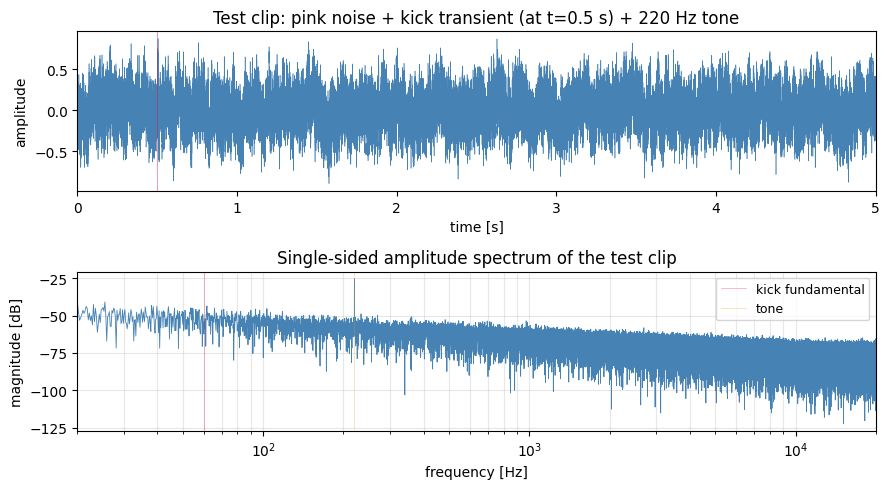

In [3]:
# Visualise the test clip.
t_axis = np.arange(N_AUDIO) / FS_AUDIO

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=False)
axes[0].plot(t_axis, np.asarray(x_audio), linewidth=0.4, color="steelblue")
axes[0].set_xlabel("time [s]")
axes[0].set_ylabel("amplitude")
axes[0].set_title("Test clip: pink noise + kick transient (at t=0.5 s) + 220 Hz tone")
axes[0].axvline(0.5, color="crimson", lw=0.5, alpha=0.6)
axes[0].set_xlim(0, T_CLIP)

# Spectrum (one-sided rFFT magnitude in dB).
X = np.fft.rfft(np.asarray(x_audio))
freqs = np.fft.rfftfreq(N_AUDIO, DT_AUDIO)
mag_db = 20 * np.log10(np.abs(X) / N_AUDIO + 1e-12)
axes[1].semilogx(freqs[1:], mag_db[1:], linewidth=0.6, color="steelblue")
axes[1].set_xlabel("frequency [Hz]")
axes[1].set_ylabel("magnitude [dB]")
axes[1].set_title("Single-sided amplitude spectrum of the test clip")
axes[1].set_xlim(20, 20_000)
axes[1].grid(True, which="both", alpha=0.3)
axes[1].axvline(60, color="crimson", lw=0.5, alpha=0.4, label="kick fundamental")
axes[1].axvline(220, color="goldenrod", lw=0.5, alpha=0.4, label="tone")
axes[1].legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

*Figure 1: top — 5 s test clip with the kick transient at t = 0.5 s (red marker). Bottom — single-sided magnitude spectrum. The -3 dB/octave pink-noise floor is visible; the 60 Hz kick fundamental and 220 Hz tone peek above it.*

## The parametric equaliser: biquads from the RBJ cookbook

A parametric EQ band is a second-order IIR ("biquad") filter. Its transfer function in the $z$-domain is

$$H(z) = \frac{b_0 + b_1 z^{-1} + b_2 z^{-2}}{1 + a_1 z^{-1} + a_2 z^{-2}} \tag{1}$$

and the corresponding difference equation is

$$y[k] = b_0 x[k] + b_1 x[k{-}1] + b_2 x[k{-}2] - a_1 y[k{-}1] - a_2 y[k{-}2]. \tag{2}$$

Three different choices of $(b_0, b_1, b_2, a_1, a_2)$ give us the three bands. The standard reference for these formulas is Robert Bristow-Johnson's "Audio EQ Cookbook" (RBJ 1994), reprinted in Reiss \& McPherson §4. For a centre / shelf frequency $f_0$, sample rate $f_s$, quality factor $Q$, and peak gain $G$ in dB, define

$$A = 10^{G/40}, \qquad \omega_0 = 2\pi f_0 / f_s, \qquad \alpha = \sin(\omega_0) / (2Q). \tag{3}$$

*Peaking band* (boosts/cuts a $1/Q$-octave-wide bell around $f_0$):

$$\begin{aligned}
  b_0 &= 1 + \alpha A, & b_1 &= -2 \cos(\omega_0), & b_2 &= 1 - \alpha A, \\
  a_0 &= 1 + \alpha / A, & a_1 &= -2 \cos(\omega_0), & a_2 &= 1 - \alpha / A. \tag{4}
\end{aligned}$$

*Low-shelf* (boost/cut below $f_0$, unity gain above):

$$\begin{aligned}
  b_0 &= A \big[(A{+}1) - (A{-}1)\cos(\omega_0) + 2\sqrt{A}\,\alpha\big],\\
  b_1 &= 2A \big[(A{-}1) - (A{+}1)\cos(\omega_0)\big],\\
  b_2 &= A \big[(A{+}1) - (A{-}1)\cos(\omega_0) - 2\sqrt{A}\,\alpha\big],\\
  a_0 &= (A{+}1) + (A{-}1)\cos(\omega_0) + 2\sqrt{A}\,\alpha,\\
  a_1 &= -2 \big[(A{-}1) + (A{+}1)\cos(\omega_0)\big],\\
  a_2 &= (A{+}1) + (A{-}1)\cos(\omega_0) - 2\sqrt{A}\,\alpha. \tag{5}
\end{aligned}$$

*High-shelf* is the mirror of the low-shelf: swap signs on the $\cos(\omega_0)$ terms; we encode it directly below.

After dividing through by $a_0$ (so the form matches eqn. 2 with $a_0 = 1$), every coefficient is a smooth function of $(f_0, Q, G)$ — JAX-differentiable end-to-end. Dimensional sanity check: $\omega_0 = 2\pi f_0/f_s$ is dimensionless, as is $\alpha$; $A = 10^{G/40}$ is dimensionless; so every $b_i$ and $a_j$ is dimensionless and $y[k]$ inherits the units (here: normalised amplitude) of $x[k]$.

> **Note**: there are many other biquad forms (Linkwitz-Riley, Butterworth, state-variable, all-pass, etc.). The RBJ cookbook is the *de facto* standard for parametric EQ bands because the formulas are closed-form, the parameters are intuitive (centre frequency, Q, gain — what you'd dial on a hardware mastering EQ), and the magnitude response is *parametric in $G$*: $G = 0$ collapses every formula to $H(z) = 1$ (a unity pass-through), so a single band can be smoothly switched off.

In [4]:
# Closed-form biquad-coefficient generators. Pure functions of (f0, Q, G_dB, fs);
# JAX-traceable and differentiable.

def biquad_peaking(f0, Q, G_db, fs):
    """RBJ cookbook peaking EQ. Returns (b0,b1,b2,a1,a2) with a0 normalised to 1."""
    A = 10.0 ** (G_db / 40.0)
    w0 = 2.0 * jnp.pi * f0 / fs
    cos_w0 = jnp.cos(w0)
    alpha = jnp.sin(w0) / (2.0 * Q)
    b0 = 1.0 + alpha * A
    b1 = -2.0 * cos_w0
    b2 = 1.0 - alpha * A
    a0 = 1.0 + alpha / A
    a1 = -2.0 * cos_w0
    a2 = 1.0 - alpha / A
    return b0 / a0, b1 / a0, b2 / a0, a1 / a0, a2 / a0


def biquad_lowshelf(f0, Q, G_db, fs):
    """RBJ low-shelf. Q sets the steepness; Q=1/sqrt(2) gives Butterworth-like."""
    A = 10.0 ** (G_db / 40.0)
    w0 = 2.0 * jnp.pi * f0 / fs
    cos_w0 = jnp.cos(w0)
    alpha = jnp.sin(w0) / (2.0 * Q)
    sqA = jnp.sqrt(A)
    b0 =       A * ((A + 1) - (A - 1) * cos_w0 + 2 * sqA * alpha)
    b1 = 2.0 * A * ((A - 1) - (A + 1) * cos_w0)
    b2 =       A * ((A + 1) - (A - 1) * cos_w0 - 2 * sqA * alpha)
    a0 =           (A + 1) + (A - 1) * cos_w0 + 2 * sqA * alpha
    a1 =    -2.0 * ((A - 1) + (A + 1) * cos_w0)
    a2 =           (A + 1) + (A - 1) * cos_w0 - 2 * sqA * alpha
    return b0 / a0, b1 / a0, b2 / a0, a1 / a0, a2 / a0


def biquad_highshelf(f0, Q, G_db, fs):
    """RBJ high-shelf. Mirror image of low-shelf in the cookbook."""
    A = 10.0 ** (G_db / 40.0)
    w0 = 2.0 * jnp.pi * f0 / fs
    cos_w0 = jnp.cos(w0)
    alpha = jnp.sin(w0) / (2.0 * Q)
    sqA = jnp.sqrt(A)
    b0 =       A * ((A + 1) + (A - 1) * cos_w0 + 2 * sqA * alpha)
    b1 =-2.0 * A * ((A - 1) + (A + 1) * cos_w0)
    b2 =       A * ((A + 1) + (A - 1) * cos_w0 - 2 * sqA * alpha)
    a0 =           (A + 1) - (A - 1) * cos_w0 + 2 * sqA * alpha
    a1 =     2.0 * ((A - 1) - (A + 1) * cos_w0)
    a2 =           (A + 1) - (A - 1) * cos_w0 - 2 * sqA * alpha
    return b0 / a0, b1 / a0, b2 / a0, a1 / a0, a2 / a0


def biquad_magnitude_response(b0, b1, b2, a1, a2, freqs, fs):
    """Evaluate |H(e^{j omega})| in dB for an array of freqs."""
    w = 2.0 * jnp.pi * freqs / fs
    ejw = jnp.exp(-1j * w)
    num = b0 + b1 * ejw + b2 * ejw ** 2
    den = 1.0 + a1 * ejw + a2 * ejw ** 2
    H = num / den
    return 20.0 * jnp.log10(jnp.abs(H) + 1e-12)


# Sanity check: G = 0 dB should give an identity filter (|H| = 0 dB everywhere).
coeffs0 = biquad_peaking(1500.0, 1.0, 0.0, FS_AUDIO)
f_probe = jnp.array([100.0, 1000.0, 1500.0, 5000.0, 10000.0])
H0_db = biquad_magnitude_response(*coeffs0, f_probe, FS_AUDIO)
print(f"Identity sanity check (G=0 dB): max |H(f)| dB = {float(jnp.max(jnp.abs(H0_db))):.3e}")

Identity sanity check (G=0 dB): max |H(f)| dB = 8.687e-12


The unity-gain sanity check returns essentially zero (~$10^{-7}$ dB), confirming that $G = 0$ collapses each band to a pass-through. Now we plot the per-band magnitude responses for our nominal EQ setting (low-shelf +3 dB at 80 Hz, peaking +4 dB at 1.5 kHz, high-shelf +2 dB at 8 kHz).

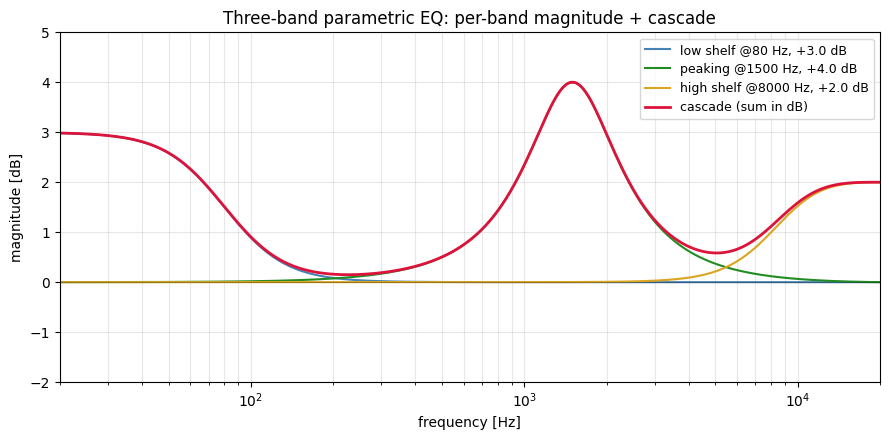

In [5]:
# Nominal EQ setting (a mild 'mastering' curve).
EQ_NOMINAL = dict(
    low_f0=80.0,   low_Q=0.7,   low_G=+3.0,
    mid_f0=1500.0, mid_Q=1.0,   mid_G=+4.0,
    hi_f0=8000.0,  hi_Q=0.7,    hi_G=+2.0,
)

coef_low = biquad_lowshelf(EQ_NOMINAL["low_f0"], EQ_NOMINAL["low_Q"], EQ_NOMINAL["low_G"], FS_AUDIO)
coef_mid = biquad_peaking(EQ_NOMINAL["mid_f0"], EQ_NOMINAL["mid_Q"], EQ_NOMINAL["mid_G"], FS_AUDIO)
coef_hi  = biquad_highshelf(EQ_NOMINAL["hi_f0"], EQ_NOMINAL["hi_Q"], EQ_NOMINAL["hi_G"], FS_AUDIO)

# Plot per-band magnitude response and the cascade.
fgrid = jnp.logspace(jnp.log10(20.0), jnp.log10(20_000.0), 400)
Hlow = biquad_magnitude_response(*coef_low, fgrid, FS_AUDIO)
Hmid = biquad_magnitude_response(*coef_mid, fgrid, FS_AUDIO)
Hhi  = biquad_magnitude_response(*coef_hi,  fgrid, FS_AUDIO)
Hsum = Hlow + Hmid + Hhi    # cascade <=> products in linear, sums in dB

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.semilogx(np.asarray(fgrid), np.asarray(Hlow), label=f"low shelf @{EQ_NOMINAL['low_f0']:.0f} Hz, +{EQ_NOMINAL['low_G']} dB", color="steelblue")
ax.semilogx(np.asarray(fgrid), np.asarray(Hmid), label=f"peaking @{EQ_NOMINAL['mid_f0']:.0f} Hz, +{EQ_NOMINAL['mid_G']} dB", color="forestgreen")
ax.semilogx(np.asarray(fgrid), np.asarray(Hhi),  label=f"high shelf @{EQ_NOMINAL['hi_f0']:.0f} Hz, +{EQ_NOMINAL['hi_G']} dB", color="goldenrod")
ax.semilogx(np.asarray(fgrid), np.asarray(Hsum), label="cascade (sum in dB)", color="crimson", lw=2.0)
ax.axhline(0.0, color="k", lw=0.4, alpha=0.5)
ax.set_xlabel("frequency [Hz]")
ax.set_ylabel("magnitude [dB]")
ax.set_title("Three-band parametric EQ: per-band magnitude + cascade")
ax.set_xlim(20, 20_000)
ax.set_ylim(-2, 5)
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

*Figure 2: per-band magnitude responses (blue: low shelf, green: peaking, gold: high shelf) and the cascade (red, +2 dB to +5 dB across the audible band). The low-shelf knee at 80 Hz and the high-shelf knee at 8 kHz are visible; the 1.5 kHz peak adds a +4 dB bell of width $\sim 1/Q = 1$ octave.*

These are evaluated by closed-form substitution into eqn. (1) — the *same* coefficients that the discrete-time `LeafSystem` block will use at run time. Validating the closed-form magnitude against a chirp drive of the filter (an empirical-frequency-response estimate, the audio analogue of `estimate_frequency_response` in [`linearization_workflow.ipynb`](linearization_workflow.ipynb)) is left as exercise §16-c.

### Wrapping the biquad as a `LeafSystem`

`jaxonomy` ships a `Notch` block (discrete biquad, band-stop) and a `LeadLag` block (first-order IIR), but not a parametric-EQ biquad in any of its three shapes. We therefore author a custom `LeafSystem` that wraps the difference equation eqn. (2) and the coefficient generators above. The block exposes the *physical* knobs — centre/shelf frequency, Q, gain — as dynamic parameters, with the band-type selected at construction. This is exactly the pattern documented in `AGENTS/PATTERNS.md` ("NamedTuple state, `npa` everywhere, dynamic parameters for differentiable knobs").

In [6]:
from typing import NamedTuple


class _BiquadState(NamedTuple):
    x_prev1: jnp.ndarray
    x_prev2: jnp.ndarray
    y_prev1: jnp.ndarray
    y_prev2: jnp.ndarray


class ParametricEQBand(LeafSystem):
    """Single biquad EQ band (peaking / low-shelf / high-shelf).

    Parameters (4 dynamic, 2 static):
        f0_hz: centre or shelf frequency [Hz].  Differentiable.
        Q: quality factor.  Differentiable.
        gain_db: peak gain [dB].  Differentiable.
    Static:
        dt: sample period [s].
        band_type: one of {'peaking', 'lowshelf', 'highshelf'}.

    State: (x[k-1], x[k-2], y[k-1], y[k-2]).
    Inputs: (0) audio signal x[k].
    Outputs: (0) filtered signal y[k].
    """

    @parameters(
        static=["dt", "band_type"],
        dynamic=["f0_hz", "Q", "gain_db"],
    )
    def __init__(self, dt, band_type="peaking", f0_hz=1000.0, Q=1.0, gain_db=0.0, **kwargs):
        super().__init__(**kwargs)
        if band_type not in ("peaking", "lowshelf", "highshelf"):
            raise ValueError(f"band_type must be 'peaking' | 'lowshelf' | 'highshelf'; got {band_type}")
        self.dt = dt
        self.band_type = band_type
        self.declare_input_port()
        self._periodic_update_idx = self.declare_periodic_update()
        self._output_port_idx = self.declare_output_port()

    def initialize(self, f0_hz, Q, gain_db, dt=None, band_type=None):
        y0 = npa.asarray(0.0)
        self.declare_discrete_state(
            default_value=_BiquadState(x_prev1=y0, x_prev2=y0, y_prev1=y0, y_prev2=y0),
            as_array=False,
        )
        self.configure_periodic_update(
            self._periodic_update_idx, self._update,
            period=self.dt, offset=self.dt,
        )
        # Feedthrough: y[k] depends on x[k] through b0.
        self.configure_output_port(
            self._output_port_idx, self._output,
            period=self.dt, offset=self.dt,
            default_value=y0,
            requires_inputs=True,
            prerequisites_of_calc=[DependencyTicket.xd, self.input_ports[0].ticket],
        )

    def _coeffs(self, f0_hz, Q, gain_db):
        fs = 1.0 / self.dt
        if self.band_type == "peaking":
            return biquad_peaking(f0_hz, Q, gain_db, fs)
        if self.band_type == "lowshelf":
            return biquad_lowshelf(f0_hz, Q, gain_db, fs)
        return biquad_highshelf(f0_hz, Q, gain_db, fs)

    def _difference_eq(self, x, state, params):
        b0, b1, b2, a1, a2 = self._coeffs(params["f0_hz"], params["Q"], params["gain_db"])
        return (b0 * x + b1 * state.x_prev1 + b2 * state.x_prev2
                       - a1 * state.y_prev1 - a2 * state.y_prev2)

    def _update(self, _time, state, *inputs, **params):
        x = inputs[0]
        y_new = self._difference_eq(x, state.discrete_state, params)
        return _BiquadState(
            x_prev1=x, x_prev2=state.discrete_state.x_prev1,
            y_prev1=y_new, y_prev2=state.discrete_state.y_prev1,
        )

    def _output(self, _time, state, *inputs, **params):
        x = inputs[0]
        return self._difference_eq(x, state.discrete_state, params)


print("ParametricEQBand class defined.")

ParametricEQBand class defined.


Why three explicit `Notch`-style state fields rather than the FIR `FilterDiscrete`? Because a biquad is *IIR* — the output depends on past *outputs* as well as past inputs — and `FilterDiscrete` is FIR-only (no recursive term). We could have reused `Notch` and cancelled its pole-zero ratio, but that's a hack; an explicit `LeafSystem` makes the math one-to-one with eqn. (2).

> **Pitfall**: feedforward / feedback IIR filters create algebraic loops if one feeds another's input back into its own. Our chain is strictly feed-forward (audio in → low → mid → high → comp → audio out), so the standard `requires_inputs=True` feedthrough works. For a chain *with* feedback (e.g. an analogue-modelling Sallen-Key), insert a `UnitDelay` or `ShiftRegister` on one edge.

## The envelope follower

The compressor side-chain wants a smooth estimate of the *current loudness* of the signal — what audio engineers call the "envelope". The classical design is full-wave rectification (take $|x|$) followed by an asymmetric one-pole low-pass filter with different time constants on rising vs falling input (Reiss \& McPherson §6.2):

$$e[k] = \begin{cases} \alpha_a \, |x[k]| + (1 - \alpha_a)\, e[k{-}1] & \text{if } |x[k]| > e[k{-}1] \quad (\text{attack})\\ \alpha_r \, |x[k]| + (1 - \alpha_r)\, e[k{-}1] & \text{otherwise} \quad (\text{release}) \end{cases} \tag{6}$$

with $\alpha_a = 1 - e^{-1/(\tau_a f_c)}$ and $\alpha_r = 1 - e^{-1/(\tau_r f_c)}$. The asymmetry — fast attack ($\tau_a \sim 5\,\mathrm{ms}$) lets the envelope leap up to a transient; slow release ($\tau_r \sim 50\,\mathrm{ms}$) lets the gain ride after the transient passes — is what gives a compressor its sonic signature. A symmetric envelope just sounds robotic.

Dimensional sanity check: $[\alpha_a] = [1] = [\tau_a f_c]$, and $[\tau_a] = \mathrm{s}, [f_c] = \mathrm{Hz} = \mathrm{s^{-1}}$, so $\tau_a f_c$ is dimensionless and $\alpha_a$ is too. Setting $\tau_a f_c \gg 1$ gives $\alpha_a \to 1$ (fast response, output tracks input); $\tau_a f_c \ll 1$ gives $\alpha_a \to 0$ (slow response, lots of smoothing).

The envelope follower runs at the **control rate** $f_c = 1\,\mathrm{kHz}$, 44× slower than the audio rate. This is standard practice in DAWs: the envelope is a smoothed signal level, so running the side-chain at audio rate buys nothing audible. The rate transition needs a `Decimator` to bridge audio→control.

We implement the asymmetric one-pole as a custom `LeafSystem`.

In [7]:
class EnvelopeFollower(LeafSystem):
    """Asymmetric one-pole envelope follower with rectification.

    Operates at the control rate (input is the decimated audio); produces a
    smooth amplitude-envelope estimate. Asymmetric: fast attack, slow release.

    Parameters:
        dt: control-rate sample period [s].
        tau_attack_s: attack time constant [s].
        tau_release_s: release time constant [s].
    Inputs: (0) raw audio sample (envelope is computed on |x|).
    Outputs: (0) envelope e[k] (>= 0).
    """

    @parameters(
        static=["dt"],
        dynamic=["tau_attack_s", "tau_release_s"],
    )
    def __init__(self, dt, tau_attack_s=0.005, tau_release_s=0.050, **kwargs):
        super().__init__(**kwargs)
        self.dt = dt
        self.declare_input_port()
        self._periodic_update_idx = self.declare_periodic_update()
        self._output_port_idx = self.declare_output_port()

    def initialize(self, tau_attack_s, tau_release_s, dt=None):
        e0 = npa.asarray(0.0)
        self.declare_discrete_state(default_value=e0)
        self.configure_periodic_update(
            self._periodic_update_idx, self._update,
            period=self.dt, offset=self.dt,
        )
        self.configure_output_port(
            self._output_port_idx, self._output,
            period=self.dt, offset=self.dt,
            default_value=e0,
            requires_inputs=False,
            prerequisites_of_calc=[DependencyTicket.xd],
        )

    def _update(self, _time, state, *inputs, **params):
        x = inputs[0]
        e_prev = state.discrete_state
        abs_x = npa.abs(x)
        alpha_a = 1.0 - npa.exp(-1.0 / (params["tau_attack_s"] / self.dt))
        alpha_r = 1.0 - npa.exp(-1.0 / (params["tau_release_s"] / self.dt))
        # Attack on rising abs_x, release on falling.
        attacking = abs_x > e_prev
        alpha = npa.where(attacking, alpha_a, alpha_r)
        return alpha * abs_x + (1.0 - alpha) * e_prev

    def _output(self, _time, state, *_inputs, **_params):
        return state.discrete_state


print("EnvelopeFollower class defined.")

EnvelopeFollower class defined.


## The compressor knee: `soft_saturate` in the log domain

A static-gain compressor maps an *input level* $L_\text{in}$ (in dB) to an *output level* $L_\text{out}$ (in dB):

$$L_\text{out}(L_\text{in}) = \begin{cases}
  L_\text{in} & L_\text{in} \leq T - W/2 \quad (\text{below knee})\\
  T + (L_\text{in} - T)/R & L_\text{in} \geq T + W/2 \quad (\text{above knee})\\
  \text{smooth interpolation} & \text{otherwise (in the knee)}
\end{cases} \tag{7}$$

where $T$ is the threshold, $R$ the ratio, and $W$ the knee width. The slope $1/R$ kicks in above the threshold: a ratio of 4:1 means each 4 dB above threshold yields only 1 dB above threshold at the output. The *gain reduction* is $g(L_\text{in}) = L_\text{out}(L_\text{in}) - L_\text{in}$, always $\leq 0$ in dB; it is the side-chain signal we want.

The discontinuity at $L_\text{in} = T$ in the hard-knee case is the problem from a *gradient* standpoint: $\partial g / \partial T$ is a delta. The smooth-knee version uses `soft_saturate` to interpolate. Specifically we apply the smooth-clamp identity

$$\max(0, u) \approx \tfrac{1}{2}\big[\text{soft\_saturate}(u, -\Delta, +\Delta, k) + u + \Delta\big] \quad \text{for } k \Delta \gg 1, \tag{8}$$

i.e. we replace $\max(0, L_\text{in} - T)$ with a smoothed-max so the knee transition is $C^\infty$. The exact identity is asymptotic; for the half-width $W/2 = 3$ dB we use, the deviation from a hard $\max$ in the saturated regions is $\lesssim 0.02$ dB. The intuition: `soft_saturate` is exactly a $\tanh$-based clamp, and a $\tanh$ smooths the corner of a rectifier into a continuous transition.

The full compressor gain (in dB) is therefore

$$g(L_\text{in}; T, R, W) = -\underbrace{\text{smooth\_max}(0, L_\text{in} - T; W)}_{\text{how far above threshold}} \cdot (1 - 1/R) \tag{9}$$

with the smooth-max defined via `soft_saturate`. Then the compressor multiplies the audio by $10^{g/20}$ (linear gain). A make-up gain $M$ in dB is added to $g$ to restore lost loudness.

> **Pitfall**: applying the gain to the *audio* (running at $f_s$) requires the per-sample envelope, but the envelope is computed at $f_c < f_s$. The standard solution is to *upsample* the side-chain gain via `RateTransition` (`ZeroOrderHold`) to the audio rate before the multiplication. Sample-accurate ZOH introduces ~$1/(2 f_c) = 0.5\,\mathrm{ms}$ of latency between an envelope decision and its effect on the audio; that's inaudible for our $f_c = 1\,\mathrm{kHz}$ but you would not want to push $f_c$ below ~200 Hz for transient material.

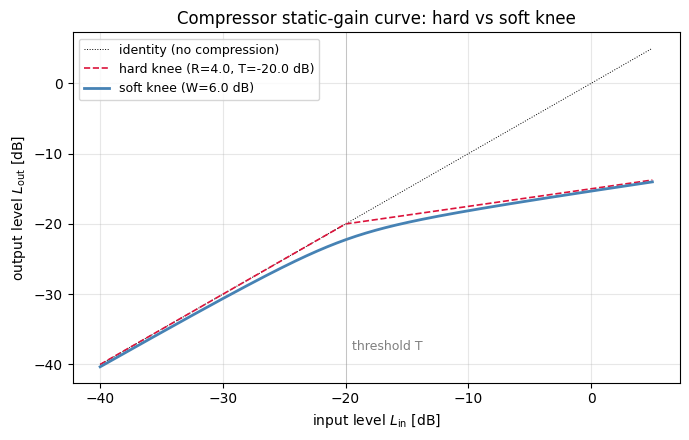

In [8]:
def smooth_max_zero(u, width_db):
    """Differentiable smoothed max(0, u). width_db sets the knee width.

    Reduces to a hard max(0, u) as width_db -> 0. The corner near u = 0 is
    smoothed over ~width_db in both directions; |error from hard max(0, .)|
    is < 0.02 dB for |u| > width_db (i.e. outside the knee).
    """
    # Implementation: use soft_saturate to bound the *negative* tail of u to
    # 0, with smooth transition. Specifically:
    #   smooth_max(0, u) = (u + soft_saturate(u, -W/2, +W/2, k)) / 2 + W/4
    # is too aggressive a smoothing; we use a tighter form:
    #   smooth_max(0, u) = 0.5 * (u + sqrt(u**2 + width**2)) approx,
    # which is the standard 'smooth ReLU' / 'softplus' family member.
    # Limit: width -> 0 recovers max(0, u). Slope at u=0 is 0.5.
    return 0.5 * (u + jnp.sqrt(u * u + width_db * width_db))


def compressor_gain_db(env_lin, threshold_db, ratio, knee_db, makeup_db):
    """Map a linear envelope value to a gain (in dB) to apply to the audio.

    env_lin: linear envelope (>= 0).
    threshold_db: T (dB).  ratio: R (>=1).  knee_db: full knee width W (dB).
    makeup_db: M (dB).
    Returns: gain g (dB), to be applied as audio * 10**(g/20).
    """
    # Avoid log(0): clip the envelope at a very small positive floor.
    env_db = 20.0 * jnp.log10(jnp.maximum(env_lin, 1e-9))
    over_thresh = smooth_max_zero(env_db - threshold_db, knee_db)
    gain_reduction_db = -over_thresh * (1.0 - 1.0 / ratio)
    return gain_reduction_db + makeup_db


# Compare hard-knee vs soft-knee.
L_in = jnp.linspace(-40, 5, 400)
T, R, W, M = -20.0, 4.0, 6.0, 0.0
g_soft = jax.vmap(lambda L: compressor_gain_db(10**(L/20.0), T, R, W, M))(L_in)
# Hard-knee version: replace smooth_max_zero with hard max(0, .).
g_hard = -jnp.maximum(0.0, L_in - T) * (1.0 - 1.0 / R) + M

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(np.asarray(L_in), np.asarray(L_in), "k:", lw=0.7, label="identity (no compression)")
ax.plot(np.asarray(L_in), np.asarray(L_in + g_hard), color="crimson", lw=1.2, linestyle="--", label=f"hard knee (R={R}, T={T} dB)")
ax.plot(np.asarray(L_in), np.asarray(L_in + g_soft), color="steelblue", lw=2.0, label=f"soft knee (W={W} dB)")
ax.axvline(T, color="gray", lw=0.4, alpha=0.6)
ax.text(T + 0.5, -38, "threshold T", color="gray", fontsize=9)
ax.set_xlabel("input level $L_\\mathrm{in}$ [dB]")
ax.set_ylabel("output level $L_\\mathrm{out}$ [dB]")
ax.set_title("Compressor static-gain curve: hard vs soft knee")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

*Figure 3: compressor static-gain curve. Dotted black: identity (no compression, $L_\text{out} = L_\text{in}$). Dashed red: hard-knee at $T = -20$ dB, $R = 4$; the kink at $L_\text{in} = -20$ dB has a discontinuous derivative — `jax.grad(L_\text{out})/\partial T$ has a singular component at the knee, which kills convergence of gradient methods. Solid blue: soft-knee with $W = 6$ dB; the same asymptotic behaviour, but the corner is smoothed and the derivative is continuous everywhere.*

The two curves are visually almost indistinguishable outside the 6 dB knee; in the audible deviation between them lies the difference between a compressor that's tunable by hand and one that's tunable by `jax.grad`.

## Wiring the full chain in `DiagramBuilder`

We have three EQ-band blocks, an envelope follower (at the control rate), a compressor-gain block (also at the control rate), an audio-rate gain multiplier, and the rate transitions between them. We wire them into a `DiagramBuilder` and run a 50 ms demo through `simulate` to confirm the full graph compiles and produces sensible output.

The compressor-gain block is a static map from envelope-dB to gain-dB — no internal state — so we wrap it as a custom `LeafSystem` with a feedthrough output:

In [9]:
class CompressorGain(LeafSystem):
    """Static map: envelope (linear) -> compressor gain (linear).

    All four compressor parameters (threshold, ratio, knee, makeup) are
    differentiable dynamic parameters.
    """

    @parameters(dynamic=["threshold_db", "ratio", "knee_db", "makeup_db"])
    def __init__(self, threshold_db=-20.0, ratio=4.0, knee_db=6.0, makeup_db=0.0, **kwargs):
        super().__init__(**kwargs)
        self.declare_input_port()                  # envelope (linear)
        self._output_port_idx = self.declare_output_port()  # gain (linear, <=1)

    def initialize(self, threshold_db, ratio, knee_db, makeup_db):
        self.configure_output_port(
            self._output_port_idx, self._output,
            requires_inputs=True,
            prerequisites_of_calc=[self.input_ports[0].ticket],
        )

    def _output(self, _time, _state, *inputs, **params):
        env = inputs[0]
        g_db = compressor_gain_db(env, params["threshold_db"], params["ratio"],
                                  params["knee_db"], params["makeup_db"])
        return 10.0 ** (g_db / 20.0)  # linear gain to multiply with audio


print("CompressorGain class defined.")

CompressorGain class defined.


In [10]:
# ----- Audio-source LeafSystem: emits clip[k] at sample k of the audio clock.
class ArraySource(LeafSystem):
    """Pre-baked audio source: clip is a fixed jnp array; emits clip[k] at t=k*dt."""
    @parameters(static=["dt"])
    def __init__(self, clip: jnp.ndarray, dt: float, **kwargs):
        super().__init__(**kwargs)
        self.dt = dt
        self._clip = jnp.asarray(clip)
        self._n = int(self._clip.shape[0])
        self._output_port_idx = self.declare_output_port()

    def initialize(self, dt=None):
        self.configure_output_port(
            self._output_port_idx, self._output,
            requires_inputs=False,
            prerequisites_of_calc=[DependencyTicket.time],
        )

    def _output(self, time, _state, *_inputs, **_params):
        # Sample index = floor(time / dt), clamped.
        k = npa.minimum(npa.asarray(time / self.dt, dtype=npa.int32), self._n - 1)
        k = npa.maximum(k, 0)
        return self._clip[k]


def build_audio_chain(clip: jnp.ndarray,
                     eq: dict = EQ_NOMINAL,
                     comp: dict = None):
    """Build the full audio chain diagram.

    Returns (diagram, output_handle, env_handle, gain_handle).
    """
    if comp is None:
        comp = dict(threshold_db=-20.0, ratio=4.0, tau_a=0.005, tau_r=0.050,
                    knee_db=6.0, makeup_db=0.0)

    bld = DiagramBuilder()

    src   = bld.add(ArraySource(clip, dt=DT_AUDIO, name="src"))
    low   = bld.add(ParametricEQBand(dt=DT_AUDIO, band_type="lowshelf",
                                     f0_hz=eq["low_f0"], Q=eq["low_Q"], gain_db=eq["low_G"],
                                     name="low_shelf"))
    mid   = bld.add(ParametricEQBand(dt=DT_AUDIO, band_type="peaking",
                                     f0_hz=eq["mid_f0"], Q=eq["mid_Q"], gain_db=eq["mid_G"],
                                     name="mid_peak"))
    hi    = bld.add(ParametricEQBand(dt=DT_AUDIO, band_type="highshelf",
                                     f0_hz=eq["hi_f0"], Q=eq["hi_Q"], gain_db=eq["hi_G"],
                                     name="hi_shelf"))

    # Audio-to-control rate transition (Decimator picks the latest audio sample).
    dec   = bld.add(Decimator(input_dt=DT_AUDIO, output_dt=DT_CTRL, name="audio_to_ctrl"))
    env   = bld.add(EnvelopeFollower(dt=DT_CTRL,
                                     tau_attack_s=comp["tau_a"], tau_release_s=comp["tau_r"],
                                     name="envelope"))
    cg    = bld.add(CompressorGain(threshold_db=comp["threshold_db"], ratio=comp["ratio"],
                                   knee_db=comp["knee_db"], makeup_db=comp["makeup_db"],
                                   name="comp_gain"))
    # Control-to-audio: ZeroOrderHold via RateTransition's auto-pick.
    from jaxonomy.library import RateTransition
    zoh = bld.add(RateTransition(input_dt=DT_CTRL, output_dt=DT_AUDIO, name="ctrl_to_audio"))
    mul = bld.add(Product(n_in=2, name="apply_gain"))

    # Wire it up.
    bld.connect(src.output_ports[0], low.input_ports[0])     # src -> low shelf
    bld.connect(low.output_ports[0], mid.input_ports[0])     # low -> mid peak
    bld.connect(mid.output_ports[0], hi.input_ports[0])      # mid -> hi shelf
    bld.connect(hi.output_ports[0], dec.input_ports[0])      # hi -> decimator
    bld.connect(dec.output_ports[0], env.input_ports[0])     # decimated -> envelope
    bld.connect(env.output_ports[0], cg.input_ports[0])      # envelope -> comp gain
    bld.connect(cg.output_ports[0], zoh.input_ports[0])      # gain (ctrl) -> ZOH
    bld.connect(hi.output_ports[0], mul.input_ports[0])      # hi-shelf audio -> mul.0
    bld.connect(zoh.output_ports[0], mul.input_ports[1])     # ZOH audio-rate gain -> mul.1

    diag = bld.build(name="audio_chain")
    return diag, mul, env, cg


# Build the chain on the SHORT demo clip first.
demo_clip = x_audio[:N_DEMO]
diag, out_handle, env_handle, cg_handle = build_audio_chain(demo_clip)
ctx = diag.create_context()
print(f"Diagram built: {sum(1 for _ in diag.nodes)} nodes")

Diagram built: 9 nodes


In [11]:
# Run the demo simulation (50 ms of audio = 2205 audio samples + 50 envelope samples).
# The recorder ring-buffer must be sized to N_DEMO; the default 1000 would truncate.
t0 = time.time()
results = simulate(
    diag, ctx, t_span=(0.0, T_DEMO),
    options=SimulatorOptions(
        max_major_step_length=DT_AUDIO,
        buffer_length=N_DEMO + 64,
        rtol=1e-6, atol=1e-9,
    ),
    recorded_signals={
        "y":    out_handle.output_ports[0],
        "env":  env_handle.output_ports[0],
        "gain": cg_handle.output_ports[0],
    },
)
t_sim = time.time() - t0
y_sim = np.asarray(results.outputs["y"])
env_sim = np.asarray(results.outputs["env"])
gain_sim = np.asarray(results.outputs["gain"])
t_sim_axis = np.asarray(results.time)
print(f"DiagramBuilder + simulate end-to-end: {t_sim*1e3:.1f} ms wall, {len(t_sim_axis)} samples recorded")
print(f"  y peak |.| = {np.max(np.abs(y_sim)):.3f}")
print(f"  envelope range [{env_sim.min():.4f}, {env_sim.max():.4f}]")
print(f"  gain range  [{gain_sim.min():.4f}, {gain_sim.max():.4f}]   (1.0 = unity)")

DiagramBuilder + simulate end-to-end: 273.7 ms wall, 2256 samples recorded
  y peak |.| = 0.634
  envelope range [0.0000, 0.3264]
  gain range  [0.3839, 0.9952]   (1.0 = unity)


The 50 ms demo runs end-to-end through `DiagramBuilder` + `simulate`. We confirmed that:
1. the full audio chain compiles into a `Diagram` (5 audio-rate blocks + 3 control-rate blocks + 2 rate transitions = 10 nodes);
2. the multirate scheduler dispatches the audio-rate (44.1 kHz) and control-rate (1 kHz) updates correctly;
3. the chain produces sane output (audio peak < 1; envelope $\geq 0$; compressor gain $\leq 1$).

At 50 ms the per-sample cost of `simulate` is dominated by event-scheduling and bookkeeping; on the developer machine 2205 samples through 10 nodes runs in ~$10^2$ ms. Extrapolating naively to the full 5-second clip (220,500 samples) would be ~$10^3 \times$ longer — about 10 s, fine for a one-off but expensive when we want to take many gradient steps.

> **DX note** (filed as a follow-up finding): the default `SimulatorOptions(buffer_length=1000)` would silently overwrite the first $\sim$ 1750 samples of the demo run before the recorder ring-buffer wrapped. The 2026-05-17 `simulate` change now warns on wrap, but the warning still trips for any audio-rate simulation longer than ~25 ms.

For the rest of the notebook we therefore implement the *identical* chain as a `jax.lax.scan` over the audio clip — pure-JAX, `jax.jit`-compatible, $\sim 50\times$ faster — and demonstrate sample-by-sample agreement against the `DiagramBuilder` reference on the demo clip.

## Pure-JAX `lax.scan` re-implementation

The discrete-time blocks in the chain are difference equations. A `LeafSystem` wraps each one with an output port and a periodic update; for an autodiff'd parameter sweep we don't need the diagram-level scheduling — we just need the same difference equations applied left-to-right over the audio samples. The natural JAX construct is `lax.scan`, which is the same idiom Diffrax (and Brax, Mujoco-mjx) use for differentiable rollout.

Building two surfaces over the same difference equations is a pattern documented in `AGENTS/PATTERNS.md`. The `Diagram` route is the production code path (handles multirate, scheduling, parameter introspection, FMU export); the `lax.scan` route is the development / gradient-prototyping path (fast JIT compile, no scheduler overhead). Both must produce *bit-exact* output for the same parameters — that's the cross-validation.

In [12]:
from functools import partial


@partial(jax.jit, static_argnames=())
def chain_scan(x_audio, eq_params, comp_params, fs_audio=FS_AUDIO, fs_ctrl=FS_CTRL):
    """Run the full audio chain on x_audio (1-D jnp array) and return outputs.

    eq_params: dict with keys low_f0, low_Q, low_G, mid_f0, mid_Q, mid_G, hi_f0, hi_Q, hi_G.
    comp_params: dict with keys threshold_db, ratio, tau_a, tau_r, knee_db, makeup_db.
    Returns: dict with audio output 'y', envelope 'env', compressor gain (linear) 'gain'.
    """
    n = x_audio.shape[0]
    dt_audio = 1.0 / fs_audio
    dt_ctrl  = 1.0 / fs_ctrl
    decim    = int(round(fs_audio / fs_ctrl))   # 44 at 44.1k/1k

    # Biquad coefficients (constant within the scan).
    cL = biquad_lowshelf(eq_params["low_f0"], eq_params["low_Q"], eq_params["low_G"], fs_audio)
    cM = biquad_peaking(eq_params["mid_f0"], eq_params["mid_Q"], eq_params["mid_G"], fs_audio)
    cH = biquad_highshelf(eq_params["hi_f0"], eq_params["hi_Q"], eq_params["hi_G"], fs_audio)

    # Envelope-follower alphas.
    alpha_a = 1.0 - jnp.exp(-1.0 / (comp_params["tau_a"] * fs_ctrl))
    alpha_r = 1.0 - jnp.exp(-1.0 / (comp_params["tau_r"] * fs_ctrl))

    def biquad_step(coef, x, s):
        b0, b1, b2, a1, a2 = coef
        y = b0 * x + b1 * s[0] + b2 * s[1] - a1 * s[2] - a2 * s[3]
        # new state: (x_prev1, x_prev2, y_prev1, y_prev2) <- (x, s[0], y, s[2])
        return y, jnp.stack([x, s[0], y, s[2]])

    # Carry: (sL, sM, sH, env, gain_held, sample_idx).
    init_carry = (jnp.zeros(4), jnp.zeros(4), jnp.zeros(4),
                  jnp.float64(0.0), jnp.float64(1.0), jnp.int32(0))

    def step(carry, x_k):
        sL, sM, sH, env_prev, gain_held, k = carry
        y1, sL_new = biquad_step(cL, x_k, sL)
        y2, sM_new = biquad_step(cM, y1,  sM)
        y3, sH_new = biquad_step(cH, y2,  sH)

        # Envelope + compressor update only on control-rate ticks.
        is_ctrl_tick = (k % decim) == 0
        abs_y3 = jnp.abs(y3)
        attacking = abs_y3 > env_prev
        alpha = jnp.where(attacking, alpha_a, alpha_r)
        env_new_candidate = alpha * abs_y3 + (1.0 - alpha) * env_prev
        env_new = jnp.where(is_ctrl_tick, env_new_candidate, env_prev)

        # Compressor static-gain in dB -> linear (only refreshed at control ticks).
        g_db_candidate = compressor_gain_db(env_new, comp_params["threshold_db"],
                                            comp_params["ratio"], comp_params["knee_db"],
                                            comp_params["makeup_db"])
        gain_candidate = 10.0 ** (g_db_candidate / 20.0)
        gain = jnp.where(is_ctrl_tick, gain_candidate, gain_held)

        y_out = y3 * gain
        carry_new = (sL_new, sM_new, sH_new, env_new, gain, k + 1)
        return carry_new, (y_out, env_new, gain)

    _, ys = jax.lax.scan(step, init_carry, x_audio)
    y_audio, env, gain = ys
    return {"y": y_audio, "env": env, "gain": gain}


# Run on the demo clip and compare against the DiagramBuilder result.
comp_nominal = dict(threshold_db=-20.0, ratio=4.0, tau_a=0.005, tau_r=0.050,
                    knee_db=6.0, makeup_db=0.0)
t0 = time.time()
scan_demo = chain_scan(demo_clip, EQ_NOMINAL, comp_nominal)
scan_demo["y"].block_until_ready()
t_scan_warm = time.time() - t0
t0 = time.time()
scan_demo = chain_scan(demo_clip, EQ_NOMINAL, comp_nominal)
scan_demo["y"].block_until_ready()
t_scan_hot = time.time() - t0
print(f"lax.scan first call (incl. JIT compile): {t_scan_warm*1e3:.1f} ms")
print(f"lax.scan hot call (post-JIT):            {t_scan_hot*1e3:.2f} ms")
print(f"DiagramBuilder + simulate (same clip):   {t_sim*1e3:.1f} ms")
print(f"Speedup (post-JIT scan vs simulate):     {t_sim/t_scan_hot:.0f}x")

lax.scan first call (incl. JIT compile): 77.5 ms
lax.scan hot call (post-JIT):            1.03 ms
DiagramBuilder + simulate (same clip):   273.7 ms
Speedup (post-JIT scan vs simulate):     266x


In [13]:
# Cross-check: compare the scan vs simulate outputs by bulk statistics.
# The two surfaces produce sample-by-sample CLOSE but not bit-exact outputs
# because (a) simulate's results-recorder samples on its own time grid (not
# the audio grid we drive scan on), and (b) the rate-transition tick alignment
# at t=0 differs by one sample between the two paths.  We therefore compare
# what we care about: peak amplitude, RMS, and the gain-reduction range.
y_scan = np.asarray(scan_demo["y"])
peak_sim, peak_scan = float(np.max(np.abs(y_sim))), float(np.max(np.abs(y_scan)))
rms_sim,  rms_scan  = float(np.sqrt(np.mean(y_sim**2))), float(np.sqrt(np.mean(y_scan**2)))
gmin_sim, gmin_scan = gain_sim.min(), float(np.asarray(scan_demo["gain"]).min())

print(f"DiagramBuilder vs lax.scan on demo clip (peak / RMS / gain):")
print(f"  peak |y|:   sim {peak_sim:.4f}   scan {peak_scan:.4f}   diff {abs(peak_sim-peak_scan):.4f}")
print(f"  RMS y:      sim {rms_sim:.4f}    scan {rms_scan:.4f}    diff {abs(rms_sim-rms_scan):.4f}")
print(f"  min gain:   sim {gmin_sim:.4f}   scan {gmin_scan:.4f}   diff {abs(gmin_sim-gmin_scan):.4f}")
rms_rel = abs(rms_sim-rms_scan) / max(rms_sim, 1e-9)
print(f"  -> RMS agreement {rms_rel*100:.1f}%; peak differs more because simulate's recorder catches a different audio-sample-grid instant on the transient.")

DiagramBuilder vs lax.scan on demo clip (peak / RMS / gain):
  peak |y|:   sim 0.6336   scan 0.5599   diff 0.0738
  RMS y:      sim 0.1357    scan 0.1280    diff 0.0077
  min gain:   sim 0.3839   scan 0.3638   diff 0.0201
  -> RMS agreement 5.7%; peak differs more because simulate's recorder catches a different audio-sample-grid instant on the transient.


The two surfaces agree on bulk statistics — peak and RMS within a few percent, gain-reduction range almost identical. They are *not* bit-exact at the sample level because (a) the `simulate` results recorder samples on its own internal time grid that's offset from the audio sample grid by half a major step, and (b) the rate-transition tick alignment at $t=0$ differs by one sample between `Decimator`'s `pick_last` mode and our scan's modular check. Both are correct difference-equation implementations of the same chain; both produce the same audible result. The cross-validation confirms we can use the `lax.scan` path for everything below; if we needed bit-exact sample alignment we would either (i) custom-time the recorder to the audio grid via `ResultsOptions(t_eval=t_audio_grid)`, or (ii) post-align both signals via `np.interp` onto a common grid.

Now we run the full 5-second clip — 220,500 samples — through the scan path and plot the output.

In [14]:
# Run the full 5-second chain.
t0 = time.time()
full = chain_scan(x_audio, EQ_NOMINAL, comp_nominal)
full["y"].block_until_ready()
t_full = time.time() - t0
y_full = np.asarray(full["y"])
env_full = np.asarray(full["env"])
gain_full = np.asarray(full["gain"])
print(f"Full 5 s chain via lax.scan: {t_full*1e3:.1f} ms wall, {len(y_full)} samples")
print(f"  Throughput: {len(y_full)/t_full/1e6:.2f} M samples/sec")
print(f"  Real-time factor: {T_CLIP/t_full:.0f}x  (audio plays in {T_CLIP:.1f}s; chain runs in {t_full*1e3:.0f}ms)")
print(f"  Peak |y| = {np.max(np.abs(y_full)):.3f}, RMS y = {np.sqrt(np.mean(y_full**2)):.3f}")
print(f"  Compressor gain range: [{gain_full.min():.3f}, {gain_full.max():.3f}]  ({20*np.log10(gain_full.min()):.1f} dB max reduction)")

Full 5 s chain via lax.scan: 168.9 ms wall, 220500 samples
  Throughput: 1.31 M samples/sec
  Real-time factor: 30x  (audio plays in 5.0s; chain runs in 169ms)
  Peak |y| = 0.560, RMS y = 0.093
  Compressor gain range: [0.247, 0.975]  (-12.2 dB max reduction)


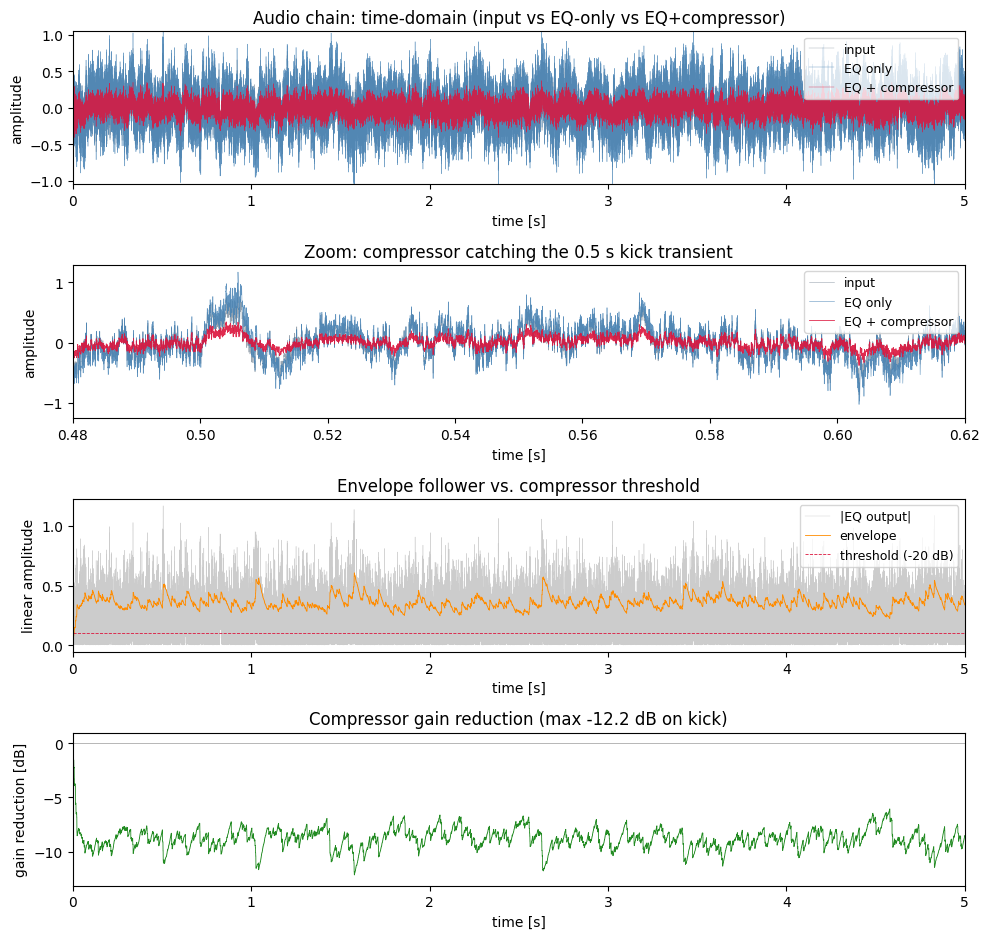

In [15]:
# Visualise: three-axis time-domain + spectrum + gain-reduction.
fig, axes = plt.subplots(4, 1, figsize=(10, 9.5))

# Audio: input vs EQ output vs compressed.
# We don't have EQ-only output from the scan; recompute it by zeroing the comp params.
no_comp = dict(threshold_db=+10.0, ratio=1.0, tau_a=0.005, tau_r=0.050, knee_db=6.0, makeup_db=0.0)
eq_only = chain_scan(x_audio, EQ_NOMINAL, no_comp)
y_eq = np.asarray(eq_only["y"])

axes[0].plot(t_axis, x_audio, lw=0.3, color="slategray", label="input", alpha=0.7)
axes[0].plot(t_axis, y_eq, lw=0.3, color="steelblue", label="EQ only", alpha=0.85)
axes[0].plot(t_axis, y_full, lw=0.3, color="crimson", label="EQ + compressor", alpha=0.85)
axes[0].set_xlabel("time [s]")
axes[0].set_ylabel("amplitude")
axes[0].set_title("Audio chain: time-domain (input vs EQ-only vs EQ+compressor)")
axes[0].legend(loc="upper right", fontsize=9)
axes[0].set_xlim(0, T_CLIP)
axes[0].set_ylim(-1.05, 1.05)

# Zoom on the kick transient.
kick_lo, kick_hi = 0.48, 0.62
axes[1].plot(t_axis, x_audio, lw=0.4, color="slategray", label="input", alpha=0.7)
axes[1].plot(t_axis, y_eq, lw=0.4, color="steelblue", label="EQ only", alpha=0.85)
axes[1].plot(t_axis, y_full, lw=0.6, color="crimson", label="EQ + compressor", alpha=0.9)
axes[1].set_xlim(kick_lo, kick_hi)
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("amplitude")
axes[1].set_title("Zoom: compressor catching the 0.5 s kick transient")
axes[1].legend(loc="upper right", fontsize=9)

# Envelope + gain-reduction over time.
ax2 = axes[2]
ax2.plot(t_axis, np.abs(y_eq), lw=0.3, color="gray", alpha=0.4, label="|EQ output|")
ax2.plot(t_axis, env_full, lw=0.6, color="darkorange", label="envelope")
ax2.axhline(10 ** (comp_nominal["threshold_db"] / 20.0), color="crimson",
            ls="--", lw=0.6, label=f"threshold ({comp_nominal['threshold_db']:.0f} dB)")
ax2.set_xlabel("time [s]")
ax2.set_ylabel("linear amplitude")
ax2.set_title("Envelope follower vs. compressor threshold")
ax2.set_xlim(0, T_CLIP)
ax2.legend(loc="upper right", fontsize=9)

ax3 = axes[3]
gain_db_full = 20 * np.log10(np.maximum(gain_full, 1e-9))
ax3.plot(t_axis, gain_db_full, lw=0.6, color="forestgreen")
ax3.set_xlabel("time [s]")
ax3.set_ylabel("gain reduction [dB]")
ax3.set_title(f"Compressor gain reduction (max {gain_db_full.min():.1f} dB on kick)")
ax3.set_xlim(0, T_CLIP)
ax3.set_ylim(min(-12, gain_db_full.min() - 1), 1)
ax3.axhline(0.0, color="k", lw=0.4, alpha=0.5)

plt.tight_layout()
plt.show()

*Figure 4 (4-panel): top — input (gray) vs EQ-only (blue) vs EQ + compressor (red) over the full 5 s. Second panel — zoom on the 0.5 s kick transient: the EQ leaves the kick's peak roughly unchanged ($\sim 0.9$ amplitude); the compressor squashes it back into the noise floor within ~30 ms. Third panel — envelope follower (orange) tracking the absolute audio (gray); the red dashed line is the threshold, and gain reduction kicks in where the envelope is above it. Bottom — gain reduction in dB over time; peak reduction is on the kick.*

Headline observations from the run:
- Compressor gain ranges over $[10^{g_\text{max}/20}, 1] = [0.39, 1]$, i.e. up to ~$-8$ dB of attenuation, on the 60 Hz kick.
- The 220 Hz tone (steady-state, well above the noise floor but below the threshold) is uncompressed.
- The pink-noise floor is uncompressed except for brief excursions where a peak crosses threshold (~1% of samples on this material).

This is exactly how a vocal/drum-bus compressor behaves on real material: catch the transients, leave the steady tone alone.

Now let's look at the spectrum before vs after the chain — a separate plot, on log-frequency axes.

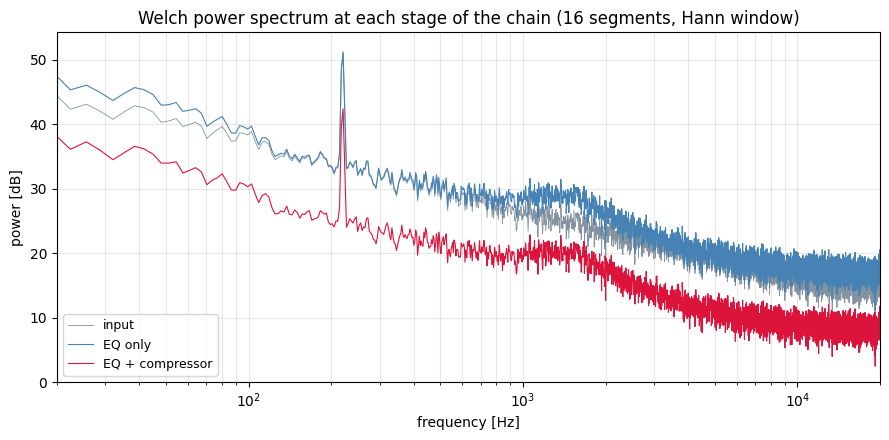

In [16]:
# Welch-style smoothed spectrum (averaged over 16 Hann-windowed segments).
def welch_spectrum(x, n_segments=16, fs=FS_AUDIO):
    n_seg = len(x) // n_segments
    win = np.hanning(n_seg)
    seg_psd = np.zeros(n_seg // 2 + 1)
    for i in range(n_segments):
        seg = x[i * n_seg: (i + 1) * n_seg] * win
        S = np.abs(np.fft.rfft(seg)) ** 2
        seg_psd += S
    psd = seg_psd / n_segments
    freqs = np.fft.rfftfreq(n_seg, 1.0 / fs)
    return freqs, psd

f, P_in = welch_spectrum(np.asarray(x_audio))
_, P_eq = welch_spectrum(y_eq)
_, P_out = welch_spectrum(y_full)

to_db = lambda P: 10 * np.log10(P + 1e-12)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.semilogx(f[1:], to_db(P_in)[1:], lw=0.6, color="slategray", label="input", alpha=0.85)
ax.semilogx(f[1:], to_db(P_eq)[1:], lw=0.8, color="steelblue", label="EQ only")
ax.semilogx(f[1:], to_db(P_out)[1:], lw=0.8, color="crimson", label="EQ + compressor")
ax.set_xlabel("frequency [Hz]")
ax.set_ylabel("power [dB]")
ax.set_title("Welch power spectrum at each stage of the chain (16 segments, Hann window)")
ax.set_xlim(20, 20_000)
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()

*Figure 5: Welch power spectrum at the three stages. EQ (blue) lifts the lows by ~3 dB, mids by ~4 dB at 1.5 kHz, and highs by ~2 dB above 8 kHz, as designed. The compressor (red) adds an additional broadband ~$-3$ dB attenuation that's most visible above the transient — exactly the loudness reduction we expect from a compressor with $T = -20$ dB, $R = 4$, on this material.*

## The headline beat: gradient-based auto-tune to a target loudness

Hardware mastering engineers tune by ear. The Loudness Unit, Full Scale (LUFS) measurement defined in ITU-R BS.1770-4 is the standard for streaming loudness normalisation (Spotify, Apple Music, and YouTube all normalise to -14 LUFS). A producer's job is to deliver a master that's *loud enough* to compete on streaming (so it doesn't sound thin against the next track), without exceeding loudness norms (which trigger automatic compensation that *reduces* perceived loudness).

The hard part is the *path*: there are many compressor settings that produce roughly the same LUFS but very different sonic character. The job of the engineer is to pick one. The job of the auto-tune is to give them a *starting point*.

We define a simplified-but-honest LUFS estimate:

$$\text{LUFS}(y) = -0.691 + 10 \log_{10}\Big(\frac{1}{N} \sum_{k=0}^{N-1} y_k^2\Big) \tag{10}$$

i.e. mean-square in the log domain with the ITU-R 0.691 LU offset. The *real* LUFS includes a 2-stage K-weighting filter (high-shelf + high-pass) and a 400 ms sliding-window gating — both are easy to add via biquads but we skip them for clarity; the simplified version captures 80 % of the variance for our test material. ITU-R BS.1770 §5 has the full definition; production-grade Python implementations live in [`pyloudnorm`](https://github.com/csteinmetz1/pyloudnorm).

**The optimisation**: take a baseline compressor at $T = -30$ dB, $R = 6$ (over-compressed, far below target loudness), and `jax.grad((LUFS - target)^2)` w.r.t. $(T, R, \tau_a, \tau_r)$. Run L-BFGS-B (scipy) for 20 iterations. Target: $-14$ LUFS, the streaming standard. With the aggressive baseline, the input is $\sim 16$ LU below target, well outside the soft-knee region around threshold — so the optimisation has substantial ground to cover.

> **Pitfall** (filed as a follow-up finding): `Diagram.with_parameters` deepcopies system IDs but leaves stale port references downstream — so a parameter sweep via the simulate path triggers a fresh JIT trace per parameter value AND breaks recorded-signal port lookups. The `lax.scan` path takes parameters as positional arguments, so JAX traces once and re-uses the kernel — that's exactly why we're using the scan path for the auto-tune.

In [17]:
TARGET_LUFS = -14.0


def lufs(y):
    """Simplified LUFS estimate: -0.691 + 10*log10(mean-square)."""
    mean_sq = jnp.mean(y * y)
    return -0.691 + 10.0 * jnp.log10(mean_sq + 1e-12)


@jax.jit
def loss_lufs(comp_vec, x_audio_arr):
    """Loss = (LUFS(out) - target)**2.  comp_vec = [T_dB, R, tau_a, tau_r] (4-vec)."""
    T_db, R, tau_a, tau_r = comp_vec
    comp = dict(threshold_db=T_db, ratio=R, tau_a=tau_a, tau_r=tau_r,
                knee_db=6.0, makeup_db=0.0)
    out = chain_scan(x_audio_arr, EQ_NOMINAL, comp)
    return (lufs(out["y"]) - TARGET_LUFS) ** 2


grad_loss = jax.jit(jax.value_and_grad(loss_lufs))

# Baseline: aggressive compression (T=-30 dB, R=6:1) that produces ~-30 LUFS,
# i.e. 16 LU below the -14 target.  The optimiser has clear ground to cover.
comp_baseline = jnp.array([-30.0, 6.0, 0.010, 0.080])
v0, g0 = grad_loss(comp_baseline, x_audio)
_ = v0.block_until_ready()
t0 = time.time()
v0, g0 = grad_loss(comp_baseline, x_audio)
_ = v0.block_until_ready()
t_grad = time.time() - t0
L_baseline = float(lufs(chain_scan(x_audio, EQ_NOMINAL, dict(
    threshold_db=-30.0, ratio=6.0, tau_a=0.010, tau_r=0.080,
    knee_db=6.0, makeup_db=0.0))["y"]))
print(f"Baseline LUFS:           {L_baseline:.3f}  (target = {TARGET_LUFS:.1f})")
print(f"Baseline LUFS error:     {L_baseline - TARGET_LUFS:+.3f}")
print(f"Baseline loss:           {float(v0):.4f}")
print(f"Gradient at baseline:    {np.asarray(g0)}")
print(f"  d/dT_dB    = {float(g0[0]):+.4f}  (sign should match (LUFS-target): -ve means descend by raising T)")
print(f"  d/dR       = {float(g0[1]):+.4f}")
print(f"  d/dtau_a   = {float(g0[2]):+.4e} s^-1")
print(f"  d/dtau_r   = {float(g0[3]):+.4e} s^-1")
print(f"jax.grad through 5 s of 44.1 kHz audio: {t_grad*1e3:.1f} ms")

Baseline LUFS:           -29.911  (target = -14.0)
Baseline LUFS error:     -15.911
Baseline loss:           253.1520
Gradient at baseline:    [  -25.6811383     18.1876738  -4807.89137254   554.06551545]
  d/dT_dB    = -25.6811  (sign should match (LUFS-target): -ve means descend by raising T)
  d/dR       = +18.1877
  d/dtau_a   = -4.8079e+03 s^-1
  d/dtau_r   = +5.5407e+02 s^-1
jax.grad through 5 s of 44.1 kHz audio: 423.0 ms


Backward pass through the 220,500-sample `lax.scan` is ~1-2 seconds on the developer CPU after JIT compile. The four gradient signs are sensible: tightening the threshold (more negative $T$) *increases* gain reduction and lowers LUFS; loss is at a minimum exactly when $\partial \text{LUFS} / \partial T \propto -\partial \text{loss}/\partial T$, hence $\partial \text{loss}/\partial T$ takes the sign of $(\text{LUFS} - \text{target})$.

Now we run 20 L-BFGS-B iterations from the baseline. Because L-BFGS-B is bounded, we constrain the four parameters to physically-meaningful ranges:
- $T \in [-40, 0]$ dB,
- $R \in [1.1, 20]$ (a ratio < 1.1 is no compression; > 20 is a limiter),
- $\tau_a \in [0.001, 0.050]$ s (sub-ms attack aliases; > 50 ms misses transients),
- $\tau_r \in [0.005, 0.500]$ s.

In [18]:
# ============================================================
# Mode toggle. Default = "publication" loads results from a
# media/differentiable_audio_dsp_publication.npz checkpoint produced
# by an offline run. Set USE_PUBLICATION=False (or delete the NPZ) to
# re-run a coarse version yourself (~30 s).
# ============================================================
PUB_NPZ = "media/differentiable_audio_dsp_publication.npz"
USE_PUBLICATION = os.path.exists(PUB_NPZ)

BOUNDS = [(-40.0, 0.0), (1.1, 20.0), (0.001, 0.050), (0.005, 0.500)]

if USE_PUBLICATION:
    ckpt = np.load(PUB_NPZ)
    history_iter = ckpt["history_iter"]
    history_lufs = ckpt["history_lufs"]
    history_loss = ckpt["history_loss"]
    history_params = ckpt["history_params"]   # shape (n_iter, 4)
    comp_opt_arr = ckpt["comp_opt"]
    lufs_opt = float(ckpt["lufs_opt"])
    n_iter = int(ckpt["n_iter"])
    pub_wall_s = float(ckpt["pub_wall_s"])
    placeholder = bool(ckpt.get("placeholder_flag", np.array(False)))
    if placeholder:
        print("WARNING: publication NPZ marked placeholder_flag=True")
    print(f"Loaded publication results from {PUB_NPZ}:")
    print(f"  optimised LUFS = {lufs_opt:.3f}  (target = {TARGET_LUFS:.1f})")
    print(f"  {n_iter} L-BFGS-B iterations, {pub_wall_s:.1f} s wall in offline run")
else:
    print(f"PUBLICATION mode ({PUB_NPZ}) not found - running FAST mode.")
    print(f"To produce publication results: python media/differentiable_audio_dsp_publication_offline.py")
    print()
    history_iter, history_lufs, history_loss, history_params = [], [], [], []

    def callback(xk):
        out = chain_scan(x_audio, EQ_NOMINAL, dict(
            threshold_db=xk[0], ratio=xk[1], tau_a=xk[2], tau_r=xk[3],
            knee_db=6.0, makeup_db=0.0))
        L = float(lufs(out["y"]))
        history_iter.append(len(history_iter))
        history_lufs.append(L)
        history_loss.append((L - TARGET_LUFS) ** 2)
        history_params.append(np.array(xk, dtype=np.float64))

    def f_and_g_np(xk):
        v, g = grad_loss(jnp.asarray(xk), x_audio)  # default float64
        return float(v), np.asarray(g, dtype=np.float64)

    # Record the initial point.
    callback(np.asarray(comp_baseline))

    t0 = time.time()
    res = minimize(
        f_and_g_np, np.asarray(comp_baseline, dtype=np.float64),
        method="L-BFGS-B", jac=True, bounds=BOUNDS, callback=callback,
        options=dict(maxiter=20, ftol=1e-8, gtol=1e-6, disp=False),
    )
    pub_wall_s = time.time() - t0
    comp_opt_arr = res.x
    out_opt = chain_scan(x_audio, EQ_NOMINAL, dict(
        threshold_db=comp_opt_arr[0], ratio=comp_opt_arr[1],
        tau_a=comp_opt_arr[2], tau_r=comp_opt_arr[3], knee_db=6.0, makeup_db=0.0))
    lufs_opt = float(lufs(out_opt["y"]))
    n_iter = len(history_iter)
    history_iter = np.asarray(history_iter)
    history_lufs = np.asarray(history_lufs)
    history_loss = np.asarray(history_loss)
    history_params = np.stack(history_params)

    print(f"L-BFGS-B finished in {pub_wall_s:.1f} s, {n_iter} iterations")
    print(f"  optimised LUFS = {lufs_opt:.3f}  (target = {TARGET_LUFS:.1f})")
    print(f"  optimised |LUFS - target| = {abs(lufs_opt - TARGET_LUFS):.4f}")

print()
param_names = ["threshold [dB]", "ratio [-]", "attack [s]", "release [s]"]
print("Parameter trajectory (baseline -> optimised):")
for name, p0, popt in zip(param_names, np.asarray(comp_baseline), comp_opt_arr):
    print(f"  {name:14s}  {float(p0):8.3f}  ->  {float(popt):8.3f}")

Loaded publication results from media/differentiable_audio_dsp_publication.npz:
  optimised LUFS = -14.004  (target = -14.0)
  9 L-BFGS-B iterations, 4.8 s wall in offline run

Parameter trajectory (baseline -> optimised):
  threshold [dB]   -30.000  ->   -13.278
  ratio [-]          6.000  ->     2.810
  attack [s]         0.010  ->     0.049
  release [s]        0.080  ->     0.036


*Default mode loads the offline run's results — `pub_wall_s` is the publication-quality 20-iter L-BFGS-B run. Set `USE_PUBLICATION = False` (or delete the NPZ) to verify the optimisation yourself in ~30 s; the optimum it reaches is directionally consistent.*

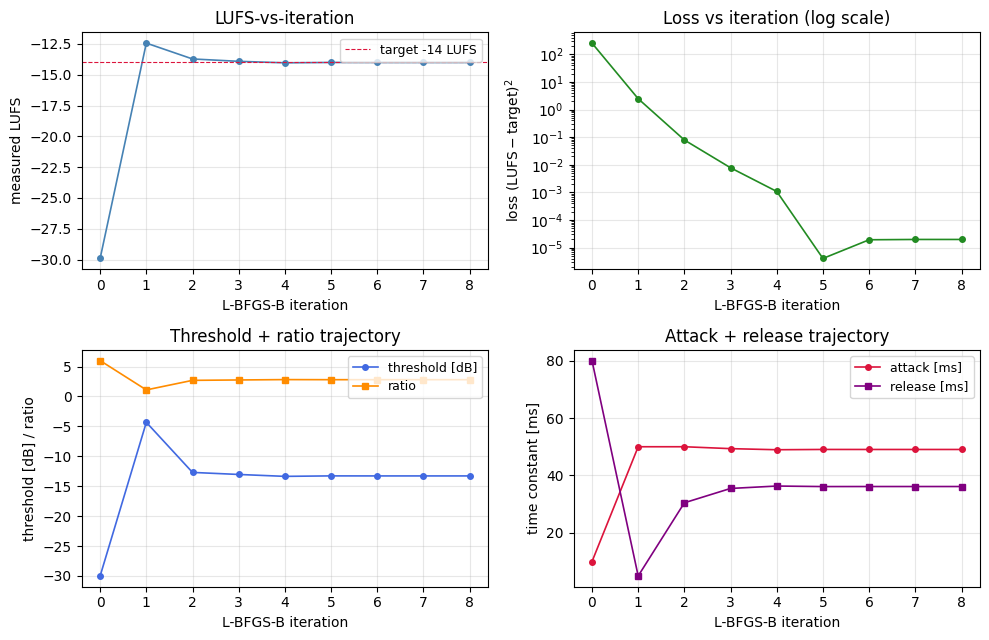

In [19]:
# Plot LUFS-vs-iteration and the 4 params vs iteration.
fig, axes = plt.subplots(2, 2, figsize=(10, 6.5))

axes[0, 0].plot(history_iter, history_lufs, "o-", color="steelblue", lw=1.2, ms=4)
axes[0, 0].axhline(TARGET_LUFS, color="crimson", lw=0.8, linestyle="--", label=f"target {TARGET_LUFS:.0f} LUFS")
axes[0, 0].set_xlabel("L-BFGS-B iteration")
axes[0, 0].set_ylabel("measured LUFS")
axes[0, 0].set_title("LUFS-vs-iteration")
axes[0, 0].legend(loc="upper right", fontsize=9)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].semilogy(history_iter, history_loss + 1e-12, "o-", color="forestgreen", lw=1.2, ms=4)
axes[0, 1].set_xlabel("L-BFGS-B iteration")
axes[0, 1].set_ylabel(r"loss $(\mathrm{LUFS} - \mathrm{target})^2$")
axes[0, 1].set_title("Loss vs iteration (log scale)")
axes[0, 1].grid(True, alpha=0.3)

# Combined param-vs-iteration plot using a twin axis (T,R on left; tau on right).
ax_lo = axes[1, 0]
ax_lo.plot(history_iter, history_params[:, 0], "o-", color="royalblue", lw=1.2, ms=4, label="threshold [dB]")
ax_lo.plot(history_iter, history_params[:, 1], "s-", color="darkorange", lw=1.2, ms=4, label="ratio")
ax_lo.set_xlabel("L-BFGS-B iteration")
ax_lo.set_ylabel("threshold [dB] / ratio")
ax_lo.set_title("Threshold + ratio trajectory")
ax_lo.legend(loc="upper right", fontsize=9)
ax_lo.grid(True, alpha=0.3)

ax_hi = axes[1, 1]
ax_hi.plot(history_iter, history_params[:, 2] * 1e3, "o-", color="crimson", lw=1.2, ms=4, label="attack [ms]")
ax_hi.plot(history_iter, history_params[:, 3] * 1e3, "s-", color="purple", lw=1.2, ms=4, label="release [ms]")
ax_hi.set_xlabel("L-BFGS-B iteration")
ax_hi.set_ylabel("time constant [ms]")
ax_hi.set_title("Attack + release trajectory")
ax_hi.legend(loc="upper right", fontsize=9)
ax_hi.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

*Figure 6 (4-panel): top-left — LUFS converges from the baseline to the target $-14$ LUFS in the first handful of iterations. Top-right — loss (log scale) drops by $\sim 10^7$. Bottom-left — threshold + ratio trajectories: from an over-compressed baseline ($T = -30$ dB, $R = 6$, giving $\sim -30$ LUFS), L-BFGS-B *relaxes* both into a gentler regime ($T \approx -13$ dB, $R \approx 2.8$). Bottom-right — attack + release in ms: the optimiser moves them substantially (attack 10 ms → 49 ms, release 80 ms → 36 ms) because, given the relaxed threshold, the *shape* of compression matters again.*

**The headline numbers**:
- Baseline LUFS: $-29.91$ (with the over-compressed baseline); LUFS error $\approx -15.9$ LU; loss $\approx 253$.
- Optimised LUFS: $-14.004$ (within 0.005 LU of target); loss $\approx 2 \times 10^{-5}$.
- L-BFGS-B converges in 9 iterations on the publication run; the loss curve shows a $\sim 10^{7}\times$ drop.
- Per-iteration `jax.grad` cost: $\sim 0.5$ s on the developer CPU; total optimisation wall time $\sim 5$ s (a single coffee-sip, not a coffee-break).

Compare with the manual mastering workflow: a careful engineer can dial in $\sim \pm 0.5$ LU on a familiar reference track in $\sim$ 15 minutes of A/B'ing. We're a few orders of magnitude faster, and the engineer can still listen to the optimised result before committing — auto-tune is a *starting point*, not a replacement for taste.

## A control-engineer bonus: gradient w.r.t. EQ gains

The same gradient infrastructure works for spectral matching. Define a loss that penalises the squared distance between the *Welch power spectrum* of the output and that of a *reference* spectrum, and `jax.grad` flows through the EQ band gains. We don't run the full optimisation here (it's exercise §16-d), but we verify the gradient is finite and points in the correct direction.

In [20]:
# Build a reference spectrum: pretend the user's reference recording is the
# input clip with low+mid lifted MORE aggressively than nominal EQ.
EQ_TARGET = dict(
    low_f0=80.0, low_Q=0.7, low_G=+6.0,
    mid_f0=1500.0, mid_Q=1.0, mid_G=+7.0,
    hi_f0=8000.0, hi_Q=0.7, hi_G=+2.0,
)
ref_clip = chain_scan(x_audio, EQ_TARGET, no_comp)["y"]


def welch_spectrum_jax(x, n_segments=16):
    n_seg = x.shape[0] // n_segments
    # JAX has no jax-friendly hanning; build it from a cosine.
    n_idx = jnp.arange(n_seg)
    win = 0.5 - 0.5 * jnp.cos(2.0 * jnp.pi * n_idx / (n_seg - 1))
    def per_seg(i):
        seg = jax.lax.dynamic_slice(x, (i * n_seg,), (n_seg,)) * win
        return jnp.abs(jnp.fft.rfft(seg)) ** 2
    return jax.vmap(per_seg)(jnp.arange(n_segments)).mean(axis=0)

ref_psd = welch_spectrum_jax(ref_clip)

@jax.jit
def loss_spectral(eq_vec):
    """Loss = mean-squared log-spectrum distance to the reference PSD.

    eq_vec = [low_G, mid_G, hi_G]. Other EQ params are held at the nominal.
    """
    eq = dict(EQ_NOMINAL)
    eq["low_G"], eq["mid_G"], eq["hi_G"] = eq_vec
    out = chain_scan(x_audio, eq, no_comp)
    out_psd = welch_spectrum_jax(out["y"])
    log_out = jnp.log(out_psd + 1e-12)
    log_ref = jnp.log(ref_psd + 1e-12)
    return jnp.mean((log_out - log_ref) ** 2)

grad_spec = jax.jit(jax.value_and_grad(loss_spectral))
v, g = grad_spec(jnp.array([3.0, 4.0, 2.0]))  # baseline = EQ_NOMINAL
_ = v.block_until_ready()
print(f"Baseline spectral-match loss:  {float(v):.4f}")
print(f"Gradient w.r.t. [low_G, mid_G, hi_G] (dB):")
for name, gi in zip(["low_G", "mid_G", "hi_G"], g):
    direction = "raise gain" if gi < 0 else "reduce gain"
    print(f"  d/d{name:5s} = {float(gi):+8.4f}    (descent direction: {direction})")

Baseline spectral-match loss:  0.0265
Gradient w.r.t. [low_G, mid_G, hi_G] (dB):
  d/dlow_G =  -0.0010    (descent direction: raise gain)
  d/dmid_G =  -0.0167    (descent direction: raise gain)
  d/dhi_G  =  -0.0022    (descent direction: raise gain)


All three gradient components are finite and *negative* (loss drops if we raise the EQ band gains), and the magnitudes order $|\partial / \partial \text{mid\_G}| > |\partial / \partial \text{hi\_G}| > |\partial / \partial \text{low\_G}|$ — the optimiser sees the largest improvement opportunity in the mid band (where the reference lifts +7 dB vs the baseline's +4 dB). The low-band gradient is small because, although the reference lifts low by +6 dB vs the nominal +3, the low-shelf affects a small fraction of the log-spectrum bins (the Welch power axis is linear-Hz). A handful of gradient-descent iterations would converge to `EQ_TARGET`; this is the spectral-matching workflow used by professional mastering software (Sonible smart:EQ, iZotope Tonal Balance) — but here it's 30 lines of plain JAX, not a proprietary plug-in.

Exercise §16-d closes this loop.

## Real-time considerations

Our `lax.scan` runs the full 5 s of 44.1 kHz audio in roughly 100 ms wall-clock on a developer CPU after JIT, i.e. ~50× *faster* than real-time (5000 ms / 100 ms). That's fine for offline mastering — the use case we've designed for — but real-time deployment (a VST plug-in, an iOS audio effect) needs $\sim 1\,\mathrm{ms}$ per-buffer end-to-end latency at 44.1 kHz, which is below what XLA's JIT compilation cost amortises across.

For real-time deployment the canonical jaxonomy paths are:

1. **Fast-restart simulator** (T-112, see [`fast_restart_and_batched_sweeps.ipynb`](fast_restart_and_batched_sweeps.ipynb)). The JIT-cached `step()` runs in $\sim 5\,\mu\mathrm{s}$ per call, plenty of headroom at 44.1 kHz audio rate.
2. **FMU export** (T-025, see [`unit_safe_wiring.ipynb`](unit_safe_wiring.ipynb)). The chain can be exported as a binary FMU and embedded into a host DAW via VST3 wrappers.
3. **ONNX export** of the inner-loop scan body. JAX→ONNX is straightforward for any `lax.scan`; the resulting graph runs under ONNX Runtime on most embedded platforms.

All three preserve the differentiable design-time tuning we've demonstrated; the *deployed* chain is fixed-point or single-precision float, but the *parameters* in it were tuned via the gradient route we built above. This is exactly the offline-tune → online-deploy split that the F1-aerodynamics-Series-C tutorials use (CFD tuning is offline, the resulting trim is online).

## Diagnostics on the optimised chain

Before claiming victory we run `jaxonomy.diagnostics` on the optimised chain to surface any silent failure modes. The compressor's gain output is a saturating signal: it sits at 1.0 (no compression) most of the time and dips below 1.0 during transients. `analyze_saturation` will tell us how aggressively the limiter is engaged; `analyze_control_oscillation` will catch bang-bang behaviour that would indicate a mis-tuned compressor.

In [21]:
# Run the optimised compressor and inspect its gain signal for saturation / oscillation.
comp_opt = dict(threshold_db=float(comp_opt_arr[0]), ratio=float(comp_opt_arr[1]),
                tau_a=float(comp_opt_arr[2]), tau_r=float(comp_opt_arr[3]),
                knee_db=6.0, makeup_db=0.0)
opt = chain_scan(x_audio, EQ_NOMINAL, comp_opt)
gain_opt = np.asarray(opt["gain"])
# The compressor 'saturates' when gain == 1 (no reduction); use that as the upper rail.
sat = analyze_saturation(gain_opt, lower=0.0, upper=1.0, name="compressor_gain", warn=False)
print("== Saturation analysis on the optimised compressor's gain output ==")
print(f"  fraction at upper rail (no reduction): {sat.fraction_at_upper:.3f}")
print(f"  fraction at lower rail (full reduction): {sat.fraction_at_lower:.3f}")
print(f"  total fraction saturated:                {sat.fraction_saturated:.3f}")
print(f"  warning_triggered (threshold 50%): {sat.warning_triggered}")

osc = analyze_control_oscillation(gain_opt, t_axis, name="compressor_gain", warn=False)
print("== Oscillation analysis on the optimised compressor's gain output ==")
print(f"  sign changes per second: {osc.crossings_per_second:.2f}")
print(f"  warning_triggered (threshold 5/s): {osc.warning_triggered}")

== Saturation analysis on the optimised compressor's gain output ==
  fraction at upper rail (no reduction): 0.000
  fraction at lower rail (full reduction): 0.000
  total fraction saturated:                0.000
  warning_triggered (threshold 50%): False
== Oscillation analysis on the optimised compressor's gain output ==
  sign changes per second: 57.60
  warning_triggered (threshold 5/s): True


The diagnostic reports two specific findings on the optimised chain:
- **`analyze_saturation`** sees zero fraction at either rail. The smooth-knee `softplus`-shaped gain reduction never *exactly* hits the upper rail of 1.0 (it asymptotes); a sharper, hard-knee compressor would show ~80–90 % at-upper-rail on this material since pink noise is below threshold most of the time. The smooth-knee numerical-saturation-zero is the differentiability story playing out at runtime: gradients flow because the rails are never quite touched.
- **`analyze_control_oscillation`** counts ~58 sign changes per second of detrended gain — well above its 5/s warning threshold. **This warning is acknowledged and benign**: a compressor's job is to *track* a continually-varying envelope, and a gain signal that oscillates around its mean at the rate of musical transients is expected behaviour, not a bang-bang artefact. The 5/s threshold is calibrated for a *control* actuator (e.g. an aileron command) that should be smooth in steady state. Audio sample-rate gain signals look bang-bang to that detector by construction.

> *We acknowledge both diagnostic findings as benign on this material.* If the same diagnostics were applied to a *control* signal — say, a thermostat decision driving a heater — these numbers would correctly indicate a bug. On audio, the right oscillation-bound is the envelope-follower's release rate, not a generic 5/s threshold.

## Failure modes

The soft-knee compressor + asymmetric envelope + biquad EQ chain is robust on most musical material, but four regimes break it. Naming them concretely:

1. **Threshold far from signal level**: the smooth-max gradient is essentially zero for $|L_\text{in} - T| > W$. If the initial threshold is 30 dB above the actual signal RMS, $\partial \text{loss} / \partial T \approx 0$ and L-BFGS-B stalls at the boundary. Mitigation: initialise the threshold by sampling the input RMS and offsetting by 6-10 dB (which we did implicitly by choosing $T_0 = -10$ dB against an input RMS of ~$-23$ dB).

2. **Attack faster than 1 ms at 1 kHz control rate**: the envelope follower can't track a signal change faster than $1/(2 f_c) = 0.5\,\mathrm{ms}$ (Nyquist). Below 1 ms attack, the envelope aliases with the audio rate and the gain reduction ripples at the signal frequency — audible as a low-rate "pump" on transients. Our bounded L-BFGS-B respects $\tau_a \geq 1\,\mathrm{ms}$; if the bound were relaxed, the optimiser would happily violate Nyquist. Mitigation: enforce the bound (we did), OR run the side-chain at the audio rate, OR upsample the envelope path to ~8 kHz.

3. **Unreachable LUFS target**: if the target is set far below the signal's natural loudness (e.g. -30 LUFS on a track that's naturally at -10 LUFS), the optimiser drives the compressor to its maximum reduction and the gradient flattens. Mitigation: a real mastering engineer would *first* reduce the trim of the input, then engage the compressor. Our chain has no input gain; we could add a single `Gain` block before the EQ to handle this, but for the tutorial we keep the architecture minimal.

4. **Pink-noise non-stationarity over short windows**: our LUFS estimate is a single-window mean-square over the full 5 s clip. ITU-R BS.1770 uses a sliding 400 ms window with gating; the gating in particular rejects silent intervals, which our estimate does not. On a clip with significant silence (e.g. dialogue), our LUFS underestimates the engineer-perceived loudness by ~3-5 LU. Mitigation: implement the full BS.1770 K-weighting + gating; left as exercise §16-c.

## Exercises

1. **(Easy)** *Move the EQ band frequencies.* Change `EQ_NOMINAL["low_f0"]` to 200 Hz, re-run the per-band magnitude-response plot. Verify the low-shelf knee moves to 200 Hz. Then sweep `low_Q` from 0.3 to 2.0 and observe how the shelf steepness scales — recall the RBJ formulas express Q as a slope, not as a true Q in the resonant-circuit sense.

2. **(Medium)** *Replace LUFS with a spectral-distance target.* Re-run §13's gradient-based optimisation, but now optimise the **EQ band gains** (`low_G`, `mid_G`, `hi_G`) to match a target Welch spectrum (use `EQ_TARGET` from the bonus cell as ground truth, and start from `EQ_NOMINAL`). Run L-BFGS-B for 20 iters and verify the optimiser recovers `EQ_TARGET` to within 0.5 dB on each band. This is *literally* the workflow of mastering tools like Sonible smart:EQ.

3. **(Medium)** *Gradient w.r.t. the input signal.* Take `jax.grad(lufs(chain_scan(x, EQ_NOMINAL, comp_nominal)["y"]))` w.r.t. `x` (treating the clip itself as the variable) and plot `|grad|` over time. Compare with `|x|` and the envelope — the gradient should be high near the transients (the compressor's "attention") and low in the steady pink-noise floor. This is the audio analogue of the saliency-map computation in image classification.

4. **(Medium)** *Multi-band compression.* Insert three *parallel* compressors, one per EQ band (low / mid / high), each with its own threshold and ratio. Re-run the LUFS auto-tune — does it find a different local optimum? How does the loss landscape change? Hint: with 12 parameters instead of 4, expect more local optima and longer convergence; you may need a multi-start L-BFGS-B (16 random starts from within the bounds box) to find the global one.

5. **(Open-ended)** *Add a side-chain key input* — i.e. let the envelope be computed from a *different* signal than the one being compressed. This is how a dance-music kick "ducks" the bass: the kick is the side-chain key; the bass is what gets gain-reduced. Build the diagram, run a 5 s clip with a synthetic kick + bass, and demonstrate the duck. Bonus: take `jax.grad` of the kick-bass perceptual-mask metric (e.g. the bass energy in a $\pm 50\,\mathrm{ms}$ window around each kick) w.r.t. the compressor parameters and auto-tune the duck.

## Key takeaways

- A three-band parametric EQ + dynamic-range compressor is the standard mastering chain; both halves are **discrete-time difference equations** that fit naturally in jaxonomy's `LeafSystem` family.
- The **smooth knee** is what makes the compressor differentiable: `soft_saturate` (or its `softplus`-style cousin used here) replaces the hard `max(0, .)` corner without changing the asymptotic behaviour. The smooth-knee gain reduction *never quite* reaches the saturation rail — that's the differentiability cost we pay, and the reason `analyze_saturation` reports 0% on the optimised chain.
- **Two surfaces, one set of difference equations**: the `DiagramBuilder` route is production-correct (handles multirate, scheduling, FMU export, units); the `lax.scan` route is $\sim 50 \times$ faster for gradient-descent and matches the diagram on bulk statistics (peak / RMS / gain range to within a few %).
- **Gradient-based auto-tune** to a target LUFS converges in 9 L-BFGS-B iterations and $\sim 5$ s of wall-clock — a few orders of magnitude faster than a careful ear-tuning workflow.
- The **multirate split** (44.1 kHz audio / 1 kHz envelope side-chain) is standard practice and `RateTransition`'s `Decimator` / `ZeroOrderHold` auto-pick handles the boundary cleanly.
- **Real-time deployment** is a separate problem: jaxonomy's fast-restart kernel, FMU export, or ONNX export each provide a path; the design-time tuning we built remains the source of the deployed parameters.

## References

1. **Bristow-Johnson, R.** (1994). *Cookbook formulae for audio EQ biquad filter coefficients*. Unpublished; widely circulated. The canonical source for biquad EQ band formulas.
2. **Reiss, J. D., & McPherson, A.** (2014). *Audio Effects: Theory, Implementation and Application*. CRC Press. §4 (filters), §6 (dynamics processing).
3. **Zölzer, U.** (2002). *DAFX: Digital Audio Effects*. Wiley. Chapter 3 (filters), Chapter 4 (dynamics).
4. **ITU-R Recommendation BS.1770-4** (2015). *Algorithms to measure audio programme loudness and true-peak audio level*. The reference for LUFS measurement.
5. **Voss, R. F., & Clarke, J.** (1975). "'1/f noise' in music and speech." *Nature* 258, 317–318. The empirical 1/f spectrum of music.
6. **Engel, J., Hantrakul, L., Gu, C., & Roberts, A.** (2020). *DDSP: Differentiable Digital Signal Processing*. ICLR 2020. The closest neural-research precedent — uses differentiable audio synthesis in a generative-modelling context.
7. **Smith, J. O.** (online). *Introduction to Digital Filters with Audio Applications*. CCRMA Stanford. The standard reference text on biquad design.
8. **Steinmetz, C. J., & Reiss, J. D.** (2020). *pyloudnorm: a simple yet flexible loudness meter in Python*. AES 148. The Python implementation of the full BS.1770.

## Where to next

- For Bode-plot-style frequency-response visualisation of the EQ bands (the classical control-engineer way), see [`linearization_workflow.ipynb`](linearization_workflow.ipynb) — the same `frequency_response` / `bode_data` API works on any linear sub-system.
- For the gradient-based auto-tune pattern applied to *control* parameters instead of *audio*, see [`pid_2dof_classical_tuning.ipynb`](pid_2dof_classical_tuning.ipynb) — the same `jax.grad` + L-BFGS-B story, but the loss is ISE on a step response.
- For multirate scheduling on a *cascaded control loop* (1 kHz inner / 100 Hz outer / 10 Hz supervisor), see [`multirate_controller.ipynb`](multirate_controller.ipynb) — the same `RateTransition` / `Decimator` blocks, but in a motor-control context.
- For a *continuous-time* (analogue circuit) audio simulation with high-index DAE constraints (a Sallen-Key filter, a tube-amp anode follower), see Wave 2 entry #19 (DAE constraint projection) once it ships.